In [49]:
from pandas_datareader import data as pdr #read data from yahoo finance api
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.api import VAR
import sklearn.metrics as metrics

#import shap #explainable AI - XAI
from sklearn.ensemble import RandomForestRegressor
import pmdarima as pm #auto arima

In [50]:
house_df = pd.read_csv('Pit House Price.csv',
                            parse_dates=['Date'],
                            index_col=['Date'])
house_df

,15237,15235,15236,15206,15221,15212,15217,15213,15216,15241,...,15209,15232,15224,15203,15207,15211,15208,15204,15233,15112
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-31,130131.3503,68048.52669,94069.17048,63533.66348,59264.87414,59146.19408,131509.7320,70426.27384,74393.24494,175105.2271,...,72748.88007,198331.3406,39989.48964,59885.99957,43297.83128,68796.91164,94617.54013,44510.80921,80090.68118,51739.07440
2000-02-29,130244.3377,68155.85539,94091.30715,63247.14181,59347.81588,59188.47138,131542.6826,69924.98175,74714.03586,175215.6503,...,72741.49645,198672.0068,39779.63311,59345.83088,43311.49876,68712.12964,94089.32116,44453.17318,79477.83403,51872.92092
2000-03-31,130461.4227,68206.92879,94266.18197,63205.96083,59493.57538,59379.04492,131758.5483,69916.60187,74905.20362,175527.2611,...,72760.36988,198973.2198,39740.15696,59487.25349,43269.01082,69082.55704,94338.92868,44482.07708,79521.08728,52177.44367
2000-04-30,130909.0633,68375.28315,94591.97506,63283.34330,59742.96556,59755.02874,132212.5761,69802.21239,75337.71672,176340.0689,...,72947.98636,198816.7723,39693.06776,59392.70314,43112.44422,69429.31792,94687.57437,44441.31583,79346.98314,52739.46639
2000-05-31,131631.0337,68624.56572,95187.26419,63511.79888,60047.24897,60299.09940,133109.8232,70537.40009,75685.37233,177817.1138,...,73440.04379,198934.1616,39650.49165,59584.59034,43048.37056,69893.90191,95351.72923,44567.25184,79756.63413,53582.58479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-30,348447.3745,159108.03810,240710.21300,264358.49120,135450.31000,163998.30160,423272.6920,282149.60410,210806.29500,437773.0322,...,224203.07170,593216.1505,241759.50540,219482.59110,135067.63430,202721.28090,146226.74950,117986.51150,237991.89500,92574.33003
2023-12-31,348931.5366,158883.57130,241077.60690,266525.66590,135623.66760,163847.15670,424106.3329,281536.64560,211131.75460,438395.3124,...,224138.54140,598677.3021,243705.96740,218804.51430,134623.82570,202359.37740,147861.22010,119507.78570,239063.57610,93330.96441
2024-01-31,349432.3147,158424.90960,241253.44690,268251.16980,136099.47370,163840.20280,425256.6425,280785.04990,211265.59180,439372.0307,...,223902.93520,603482.5095,244993.14850,218076.40590,134285.80370,201392.03150,149569.76100,120679.90660,240040.61880,93963.81387


In [51]:
house_price=pd.DataFrame(house_df['15217'])
house_price

,15217
Date,
2000-01-31,131509.7320
2000-02-29,131542.6826
2000-03-31,131758.5483
2000-04-30,132212.5761
2000-05-31,133109.8232
...,...
2023-11-30,423272.6920
2023-12-31,424106.3329
2024-01-31,425256.6425


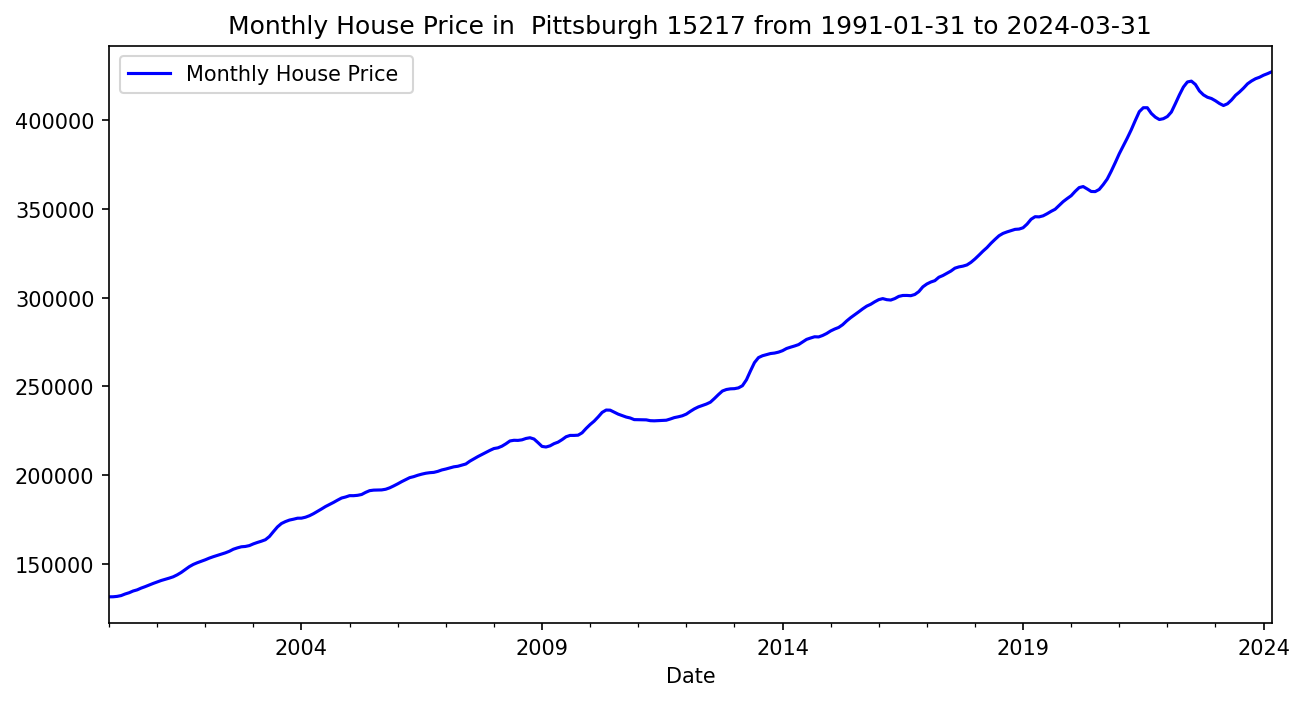

In [11]:
# Visualizing the series

# to set the plot size
plt.figure(figsize=(10, 5), dpi=150) #dpi = resolution. default 100.

# in plot method we set the label and color of the curve.
house_price['15217'].plot(label='Monthly House Price ', color='blue')

# adding title to the plot
plt.title('Monthly House Price in  Pittsburgh 15217 from {} to {}'.format('1991-01-31', '2024-03-31'))

# adding Label to the x-axis
plt.xlabel('Date')

# adding legend to the curve
plt.legend()


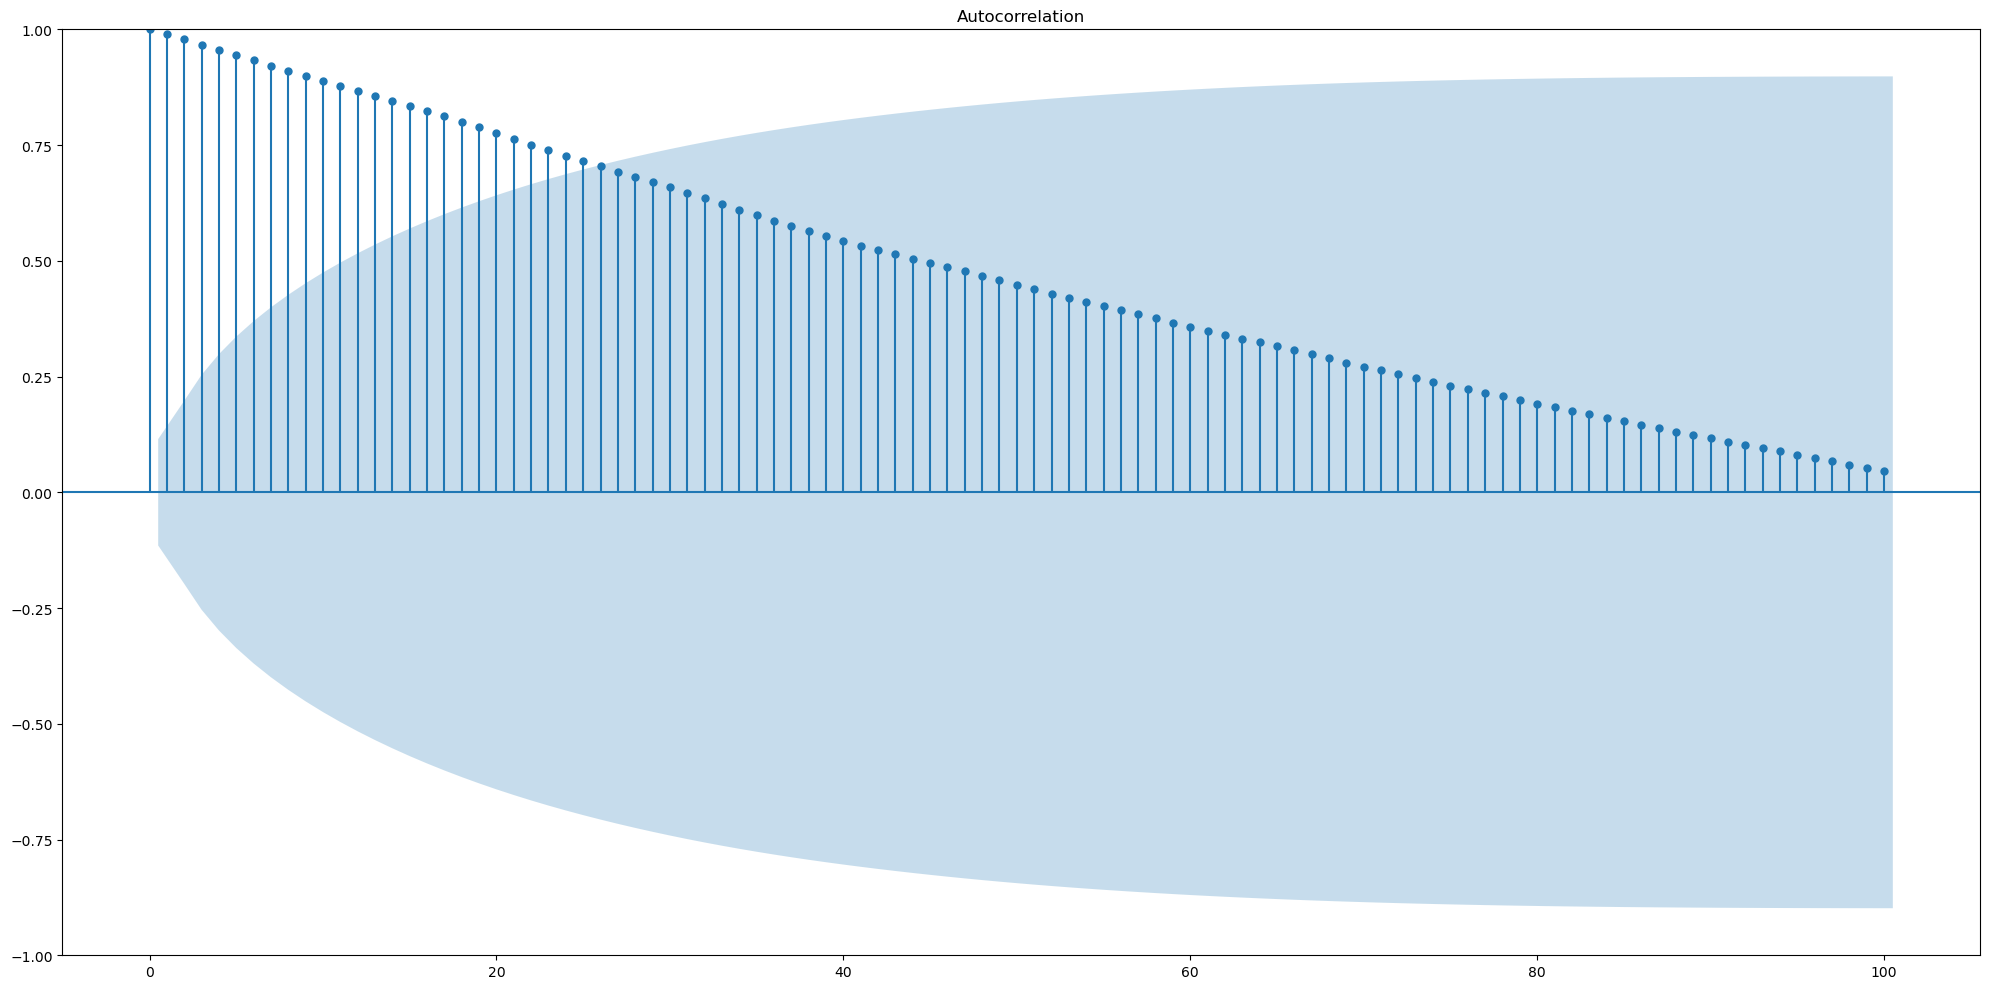

In [12]:
#check if the data is stationary

# autocorrelation plot of the dataset
fig = plot_acf(house_price, lags=100)
fig.set_size_inches((20, 10))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [13]:
result = adfuller(house_price['15217'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 1.010703
p-value: 0.994378
Critical Values:
	1%: -3.454
	5%: -2.872
	10%: -2.572


<Axes: xlabel='Date'>

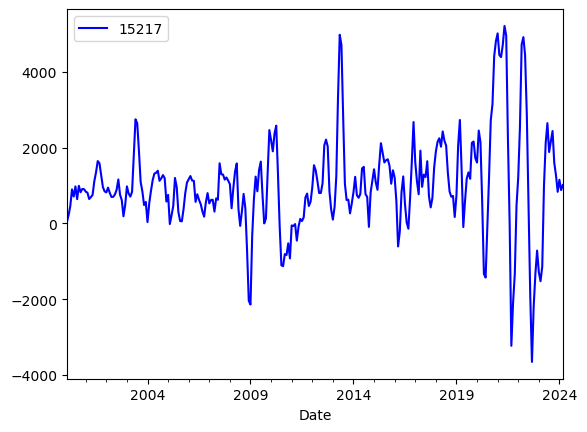

In [52]:
#create differenced dataset
first_diff_df = house_price.diff().dropna()
first_diff_df.plot(color='blue')

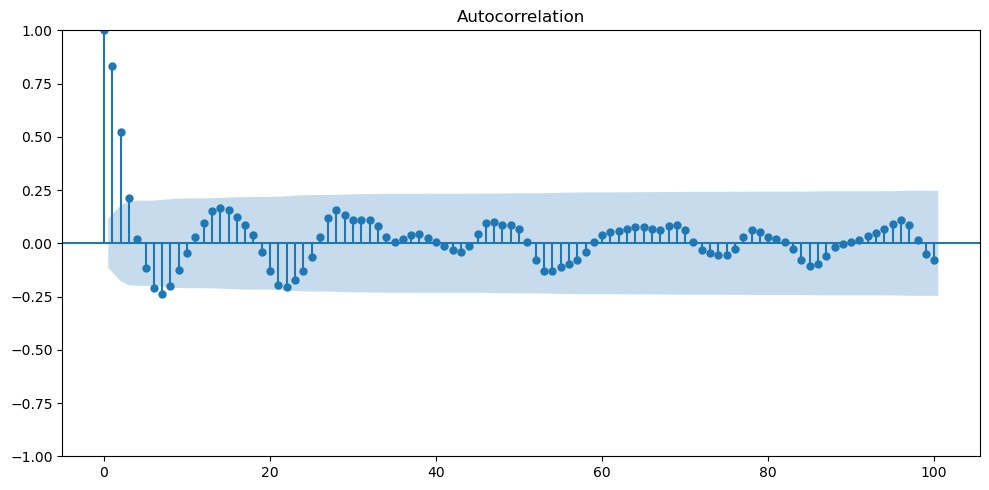

In [15]:
# autocorrelation plot of differenced dataset
fig = plot_acf(first_diff_df, lags=100)
fig.set_size_inches((10, 5))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [53]:
X = first_diff_df.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.505965
p-value: 0.007835
Critical Values:
	1%: -3.455
	5%: -2.872
	10%: -2.572


In [54]:
def split_data(df, test_start, test_end):
    
    #train_data = df[(df.index < test_start) | (df.index > test_end)]
    train_data = df[(df.index < test_start)]
    test_data = df[(df.index >= test_start) & (df.index <= test_end)]
 
    return train_data, test_data

# 4 test periods
test_periods = [
    ('2020-01-01', '2021-01-01'),
    ('2021-01-01', '2022-01-01'),
    ('2022-01-01', '2023-01-01'),
    ('2023-01-01', '2024-01-01')
]

# call function to create 4 split data sets
train_data0, test_data0 = split_data(house_price, *test_periods[0])
train_data1, test_data1 = split_data(house_price, *test_periods[1])
train_data2, test_data2 = split_data(house_price, *test_periods[2])
train_data3, test_data3 = split_data(house_price, *test_periods[3])

In [18]:
test_data0

,15217
Date,
2020-01-31,357376.7391
2020-02-29,359824.7829
2020-03-31,361964.4412
2020-04-30,362538.4900
2020-05-31,361207.6202
2020-06-30,359779.8736
2020-07-31,359700.7412
2020-08-31,360928.4944
2020-09-30,363647.0133


In [56]:
# Define your test periods if not defined
test_periods = [
    ('2020-01-01', '2021-01-01'),
    ('2021-01-01', '2022-01-01'),
    ('2022-01-01', '2023-01-01'),
    ('2023-01-01', '2024-01-01')
]


## Arima Nonseasonal

In [55]:
# function to get non_seasonal_auto_model, fc_series_auto_nonseasonal, and plot the graph

def auto_Arima_nonseasonal(train_data, test_data):   
    non_seasonal_auto_model = pm.auto_arima(train_data, start_p=0, start_q=0,
                              test='adf',       # use adftest to find optimal 'd'
                              max_p=3, max_q=3, # maximum p and q
                              m=12,              # frequency of series
                              d=None,           # let model determine 'd'
                              seasonal=False,   # No Seasonality
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

    print(non_seasonal_auto_model.summary())


    # Forecast
    n_periods = 12
    fc_auto_nonseasonal, confint = non_seasonal_auto_model.predict(n_periods=n_periods, return_conf_int=True)
#     print("\nfc_auto_nonseasonal: \n",fc_auto_nonseasonal)

    # make series for plotting purpose
    fc_series_auto_nonseasonal = pd.Series(fc_auto_nonseasonal, index=test_data.index)
#     lower_series = pd.Series(confint[:, 0], index=test_data.index)
#     upper_series = pd.Series(confint[:, 1], index=test_data.index)

#     # Plot
#     plt.figure(figsize=(12,5), dpi=100)
#     plt.plot(train_data, label='train')
#     plt.plot(test_data, label='test')
#     plt.plot(fc_series_auto_nonseasonal, color='darkgreen', label='forecast')
#     plt.fill_between(lower_series.index,
#                      lower_series,
#                      upper_series,
#                      color='k', alpha=.15)

#     plt.show()
    return fc_series_auto_nonseasonal

In [57]:
def forecastArima_nonseasonal(): 
    
    forecast_results = {}

    # Loop through each test period, split the data, run ARIMA, and store the forecast
    for i, period in enumerate(test_periods):
        train_data, test_data = split_data(house_price, *period)
        forecast = auto_Arima_nonseasonal(train_data, test_data)
        forecast_results[f'period_{i}'] = forecast

    # To display the forecast results for each period
    for period, forecast in forecast_results.items():
        print(f"Forecast for {period}: {forecast}")
        
    return forecast_results

In [58]:
arima_nonseasonal_forecasts=forecastArima_nonseasonal()

/Users/qt/anaconda3/lib/python3.11/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3912.030, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3910.737, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3911.834, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4097.456, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=3912.374, Time=0.18 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3913.695, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3914.621, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=4087.891, Time=0.05 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.743 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  240
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -1952.369
Date:                Tue, 23 Apr 2024   AIC                           3910.737
Time:                        18:58:2

/Users/qt/anaconda3/lib/python3.11/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4159.459, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4157.688, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4158.847, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4337.187, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=4198.438, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4161.616, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=4161.687, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=4326.615, Time=0.04 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.720 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  252
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -2075.844
Date:                Tue, 23 Apr 2024   AIC                           4157.688
Time:                        18:58:2

/Users/qt/anaconda3/lib/python3.11/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4454.566, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4455.669, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4609.641, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=4454.996, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4456.868, Time=0.12 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=4457.910, Time=0.16 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=4595.797, Time=0.05 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.772 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  264
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -2224.283
Date:                Tue, 23 Apr 2024   AIC                           4454.566
Time:                        18:58:25   BIC                           4465.283
Sample:                    01-31-2000   HQIC                      

/Users/qt/anaconda3/lib/python3.11/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4710.441, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4711.750, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4850.825, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=4741.896, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4713.752, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=4714.238, Time=0.19 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=4834.954, Time=0.05 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.778 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  276
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -2352.221
Date:                Tue, 23 Apr 2024   AIC                           4710.441
Time:                        18:58:26   BIC                           4721.292
Sample:                    01-31-2000   HQIC                      

In [59]:
def tripleETS(train_data, test_data):
    # triple ETS - Holt Winter's Seasonal Method
    triple_ets_add = ExponentialSmoothing(train_data, trend = 'add', seasonal = 'add', seasonal_periods=12).fit()
    triple_ets_mul = ExponentialSmoothing(train_data, trend = 'mul', seasonal = 'mul', seasonal_periods=12).fit()

    triple_ets_add_pred = triple_ets_add.forecast(12)
    triple_ets_mul_pred = triple_ets_mul.forecast(12)
    
    #plot the train, test, and predictions

    #After creating model we will visualize the plot
    ax = test_data.plot(marker='o', color='black', figsize=(20,8), legend=True)

    #Plot for double ETS additive
    triple_ets_add_pred.plot(marker='+', ax=ax, color='blue', legend=True, label = 'triple ets add')
    #triple_ets_add.fittedvalues.plot(marker='+', ax=ax, color='blue')

    #Plot for double ETS multiplicative
    triple_ets_mul_pred.plot(marker='o', ax=ax, color='red', legend=True, label = 'triple ets mul')
    #triple_ets_mul.fittedvalues.plot(marker='o', ax=ax, color='red')


    plt.title('Train, Test and Predicted Test using Triple ETS - Holt Winters Seasonal')     
    plt.show()
    return triple_ets_add_pred, triple_ets_mul_pred

In [60]:
def forecastTripleETS(): 
    
    tripleAdd_results = {}
    tripleMul_results = {}

    # Loop through each test period, split the data, run ARIMA, and store the forecast
    for i, period in enumerate(test_periods):
        train_data, test_data = split_data(house_price, *period)
        tripleAdd, tripleMul = tripleETS(train_data, test_data)
        tripleAdd_results[f'period_{i}'] = tripleAdd 
        tripleMul_results[f'period_{i}'] = tripleMul

    # To display the forecast results for each period
    for period, forecast in tripleAdd_results.items():
        print(f"Forecast for {period}: {forecast}")
    for period, forecast in tripleMul_results.items():
        print(f"Forecast for {period}: {forecast}")
        
    return   tripleAdd_results, tripleMul_results

/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


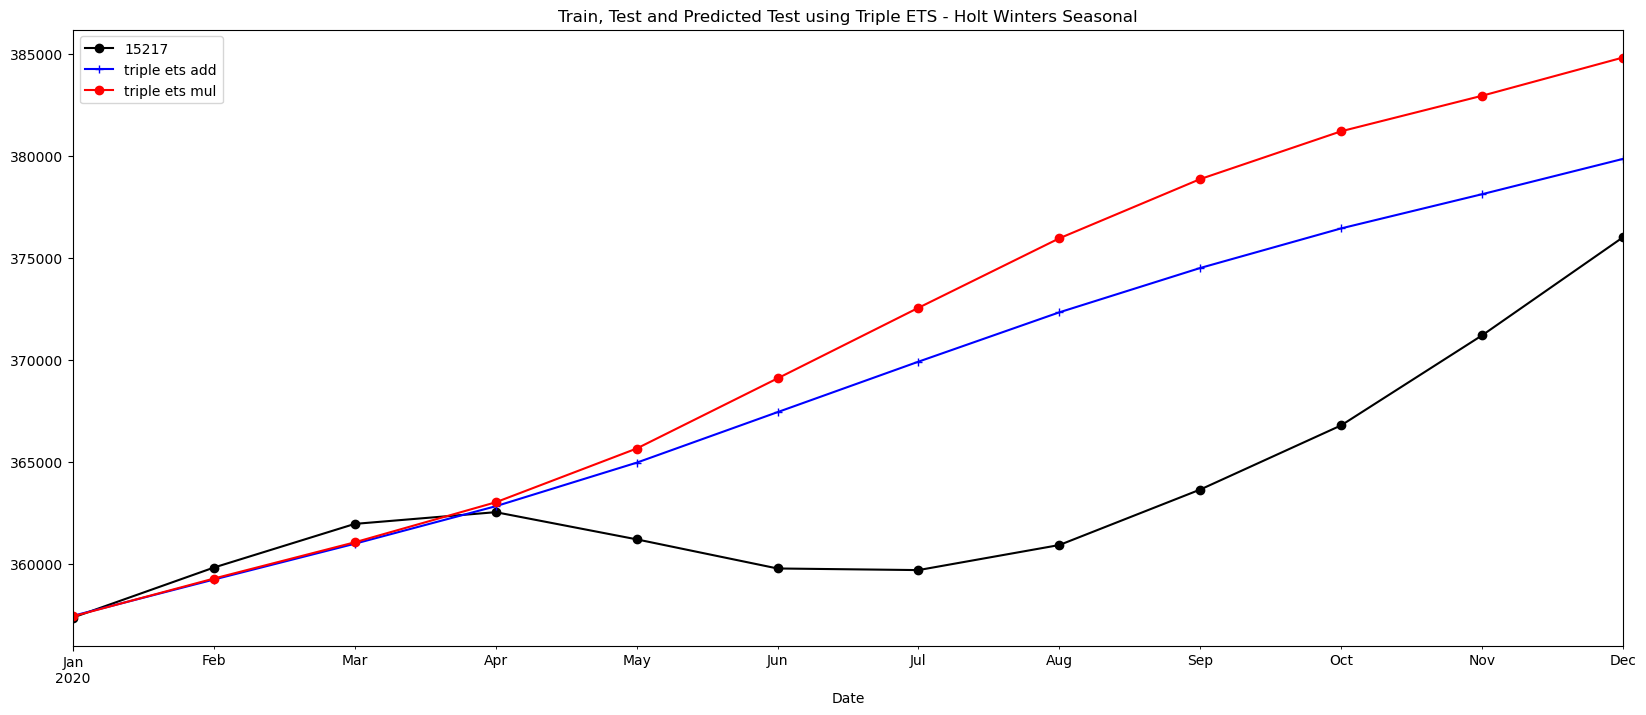

/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


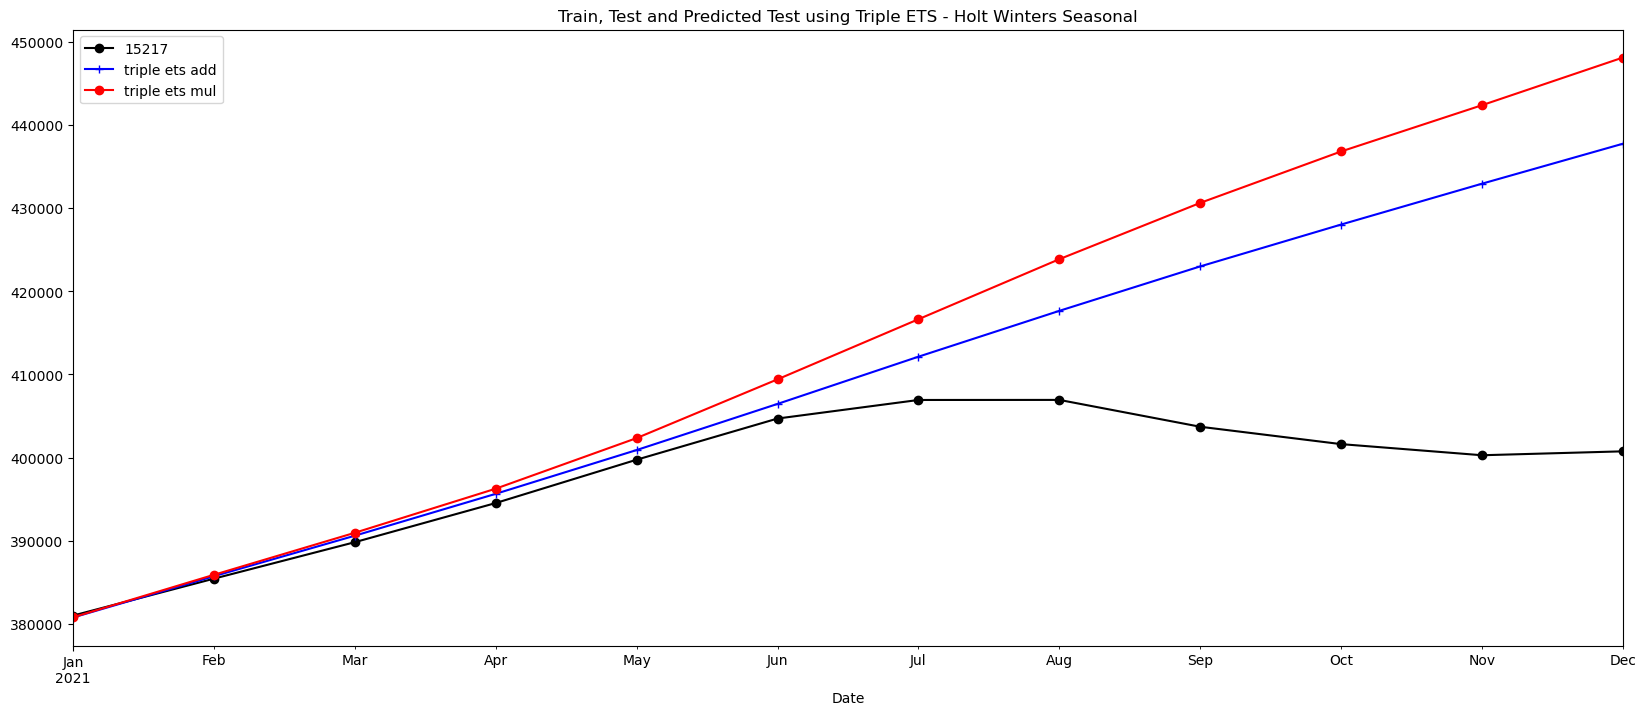

/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


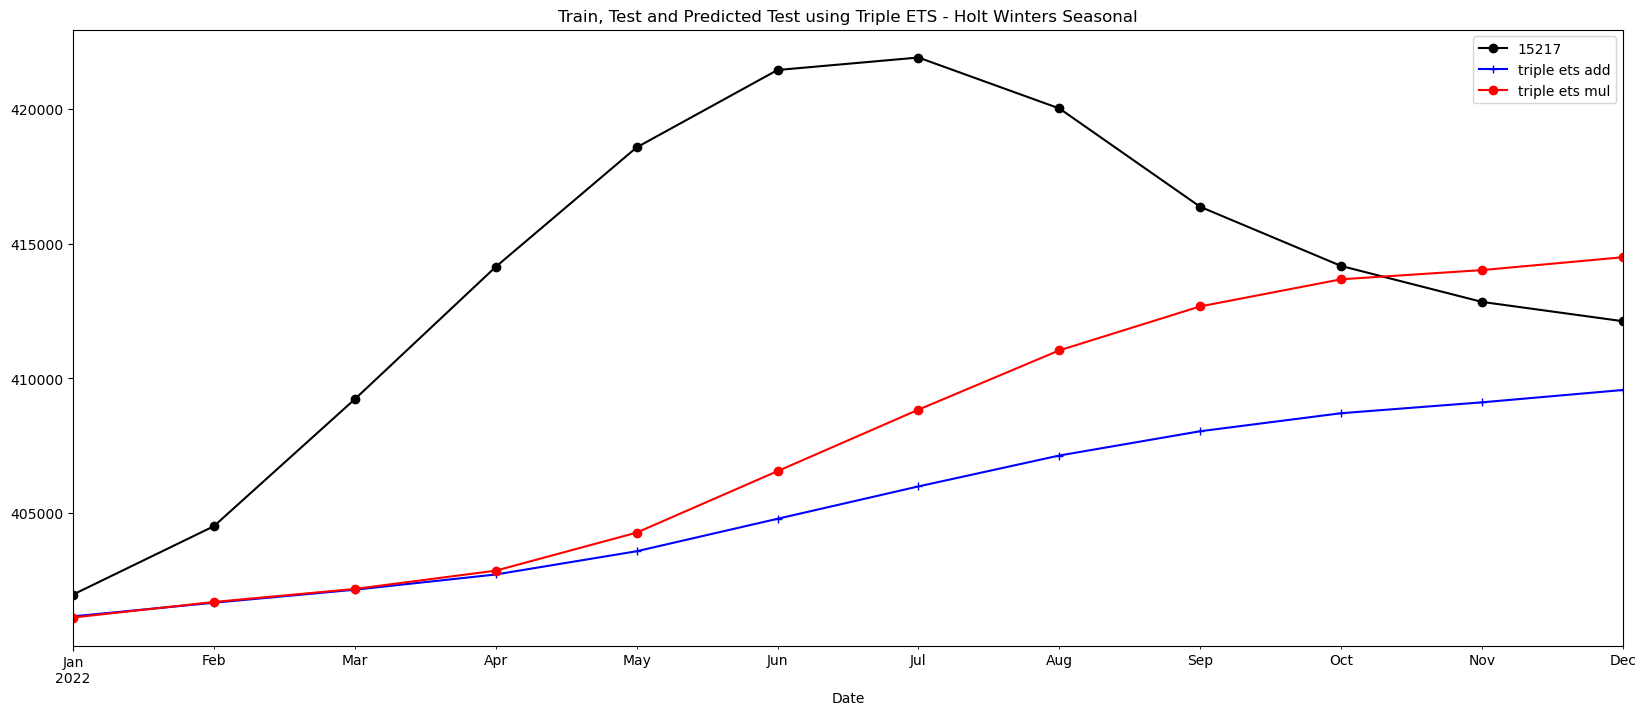

/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


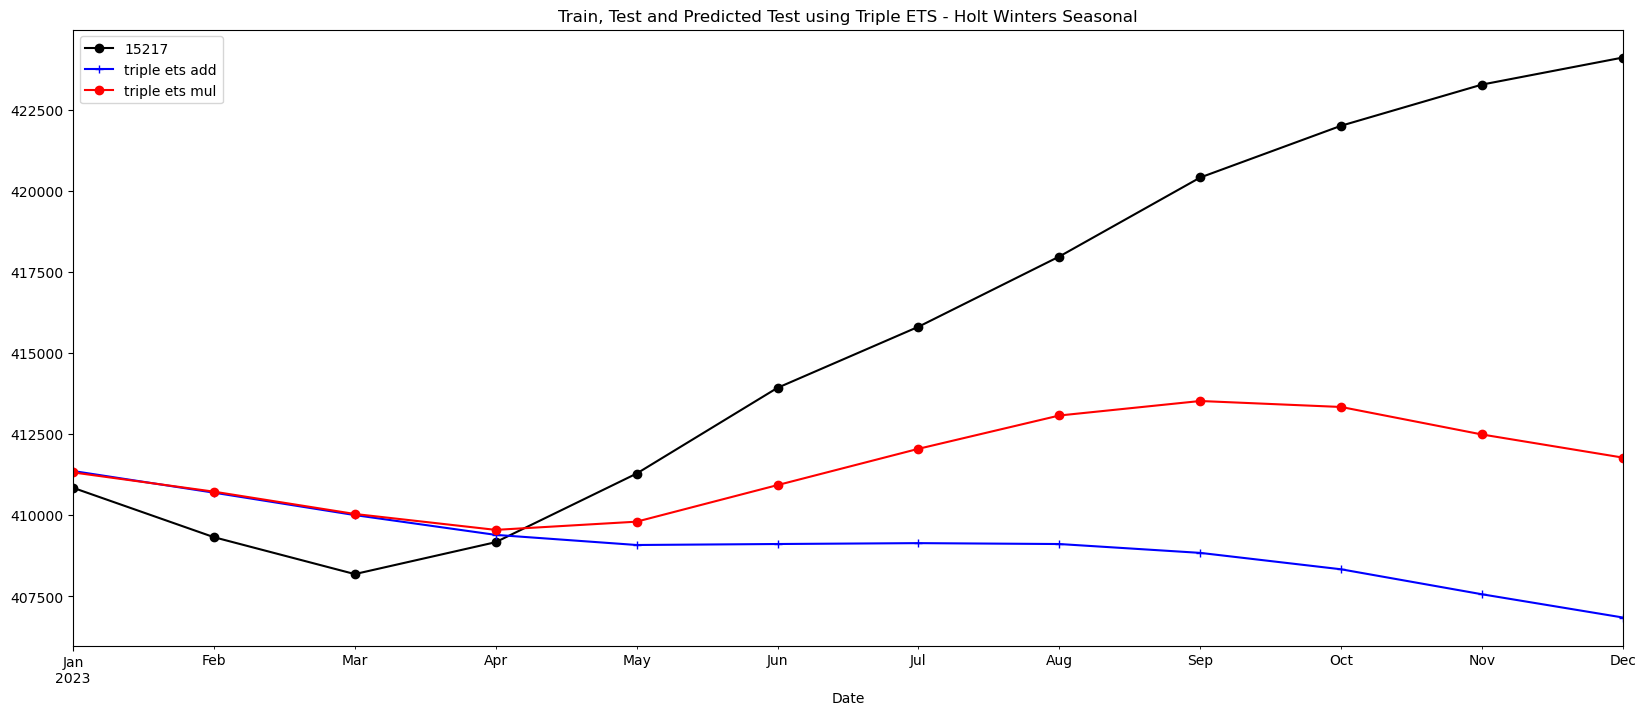

Forecast for period_0: 2020-01-31    357460.041576
2020-02-29    359237.763193
2020-03-31    360992.369744
2020-04-30    362828.424991
2020-05-31    364962.465855
2020-06-30    367438.762679
2020-07-31    369911.714323
2020-08-31    372329.845820
2020-09-30    374502.868028
2020-10-31    376442.233515
2020-11-30    378117.598361
2020-12-31    379847.377990
Freq: M, dtype: float64
Forecast for period_1: 2021-01-31    380785.347322
2021-02-28    385747.683159
2021-03-31    390619.524346
2021-04-30    395653.217646
2021-05-31    400915.937751
2021-06-30    406461.457950
2021-07-31    412136.839945
2021-08-31    417648.569030
2021-09-30    422991.275149
2021-10-31    428024.173100
2021-11-30    432936.449830
2021-12-31    437740.233552
Freq: M, dtype: float64
Forecast for period_2: 2022-01-31    401167.209605
2022-02-28    401673.683735
2022-03-31    402157.009674
2022-04-30    402721.715218
2022-05-31    403584.455246
2022-06-30    404789.607882
2022-07-31    405991.288529
2022-08-31    4

In [61]:
tripleAdd_forecasts, tripleMul_forecasts=forecastTripleETS()

In [62]:
def doubleETS(train_data, test_data):
    double_ets_add = ExponentialSmoothing(train_data, trend = 'add').fit()
    double_ets_mul = ExponentialSmoothing(train_data, trend = 'mul').fit()

    double_ets_add_pred = double_ets_add.forecast(12)
    double_ets_mul_pred = double_ets_mul.forecast(12)
    
    #plot the train, test, and predictions
    #df=train_data.append(test_data) # draw all actual data as black color
    df=(test_data)

    #After creating model we will visualize the plot
    ax = df.plot(marker='o', color='black', figsize=(20,8), legend=True)

    #Plot for double ETS additive
    double_ets_add_pred.plot(marker='+', ax=ax, color='blue', legend=True, label = 'double ets add')
    #double_ets_add.fittedvalues.plot(marker='+', ax=ax, color='blue')

    #Plot for double ETS multiplicative
    double_ets_mul_pred.plot(marker='o', ax=ax, color='red', legend=True, label = 'double ets mul')
    #double_ets_mul.fittedvalues.plot(marker='o', ax=ax, color='red')

    #Plot for simple exponential smooting alpha=Optimized by statsmodel
#     ins_cast3.plot(marker='*', ax=ax, color='green', legend=True)
#     ins3.fittedvalues.plot(marker='*', ax=ax, color='green')
    plt.title('Train, Test and Predicted Test using Holt Winters')
#     plt.show()
    
    return double_ets_add_pred, double_ets_mul_pred

In [63]:
def forecastDoubleETS(): 
    
    tripleAdd_results = {}
    tripleMul_results = {}

    # Loop through each test period, split the data, run ARIMA, and store the forecast
    for i, period in enumerate(test_periods):
        train_data, test_data = split_data(house_price, *period)
        doubleAdd, doubleMul = doubleETS(train_data, test_data)
        tripleAdd_results[f'period_{i}'] = doubleAdd 
        tripleMul_results[f'period_{i}'] = doubleMul

    # To display the forecast results for each period
    for period, forecast in tripleAdd_results.items():
        print(f"Forecast for {period}: {forecast}")
    for period, forecast in tripleMul_results.items():
        print(f"Forecast for {period}: {forecast}")
        
    return   tripleAdd_results, tripleMul_results

/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/

Forecast for period_0: 2020-01-31    357502.382872
2020-02-29    359230.348994
2020-03-31    360958.315115
2020-04-30    362686.281237
2020-05-31    364414.247359
2020-06-30    366142.213480
2020-07-31    367870.179602
2020-08-31    369598.145724
2020-09-30    371326.111845
2020-10-31    373054.077967
2020-11-30    374782.044089
2020-12-31    376510.010210
Freq: M, dtype: float64
Forecast for period_1: 2021-01-31    380811.838246
2021-02-28    385619.478005
2021-03-31    390427.117765
2021-04-30    395234.757525
2021-05-31    400042.397284
2021-06-30    404850.037044
2021-07-31    409657.676804
2021-08-31    414465.316564
2021-09-30    419272.956323
2021-10-31    424080.596083
2021-11-30    428888.235843
2021-12-31    433695.875602
Freq: M, dtype: float64
Forecast for period_2: 2022-01-31    401209.326868
2022-02-28    401665.857358
2022-03-31    402122.387848
2022-04-30    402578.918338
2022-05-31    403035.448828
2022-06-30    403491.979317
2022-07-31    403948.509807
2022-08-31    4

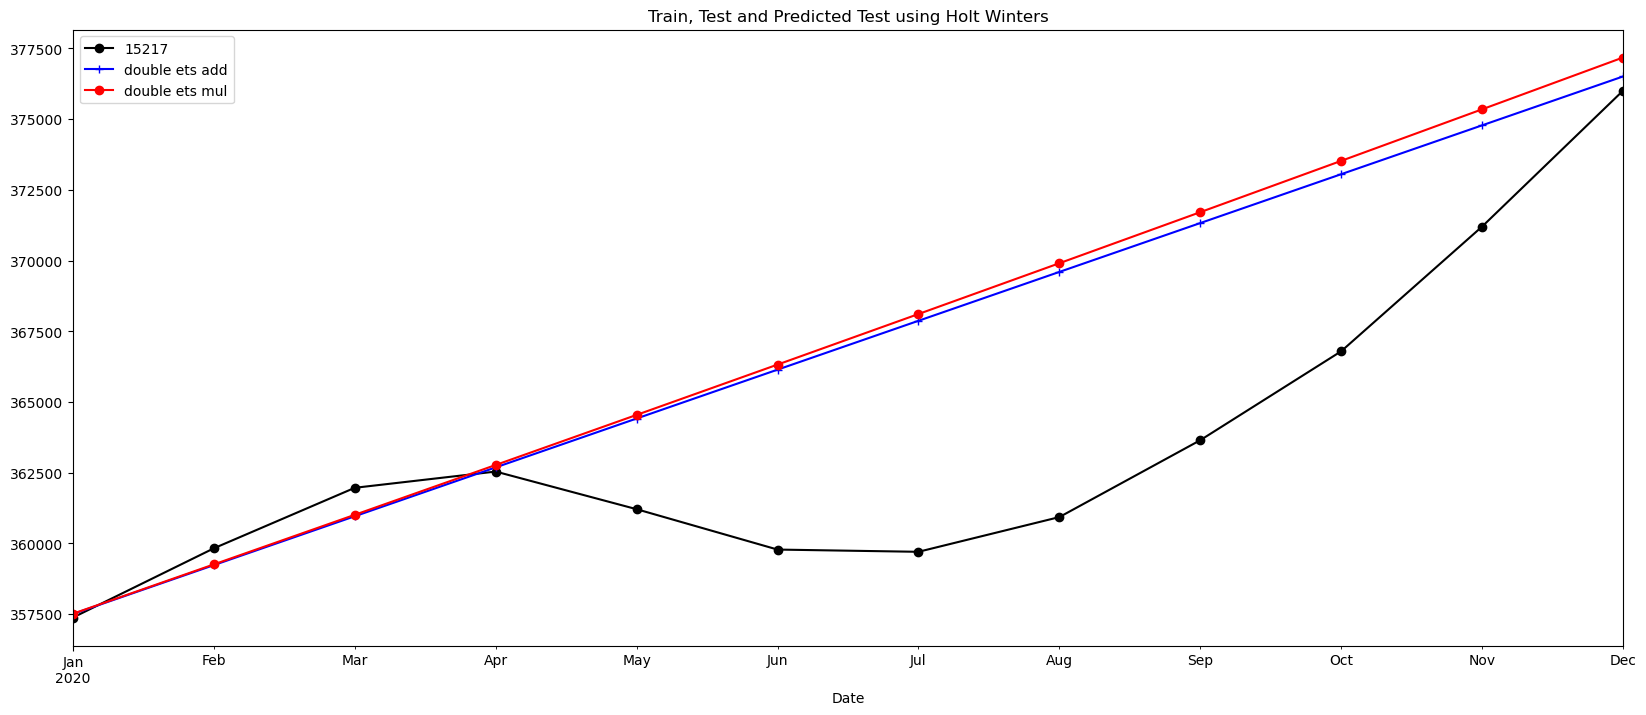

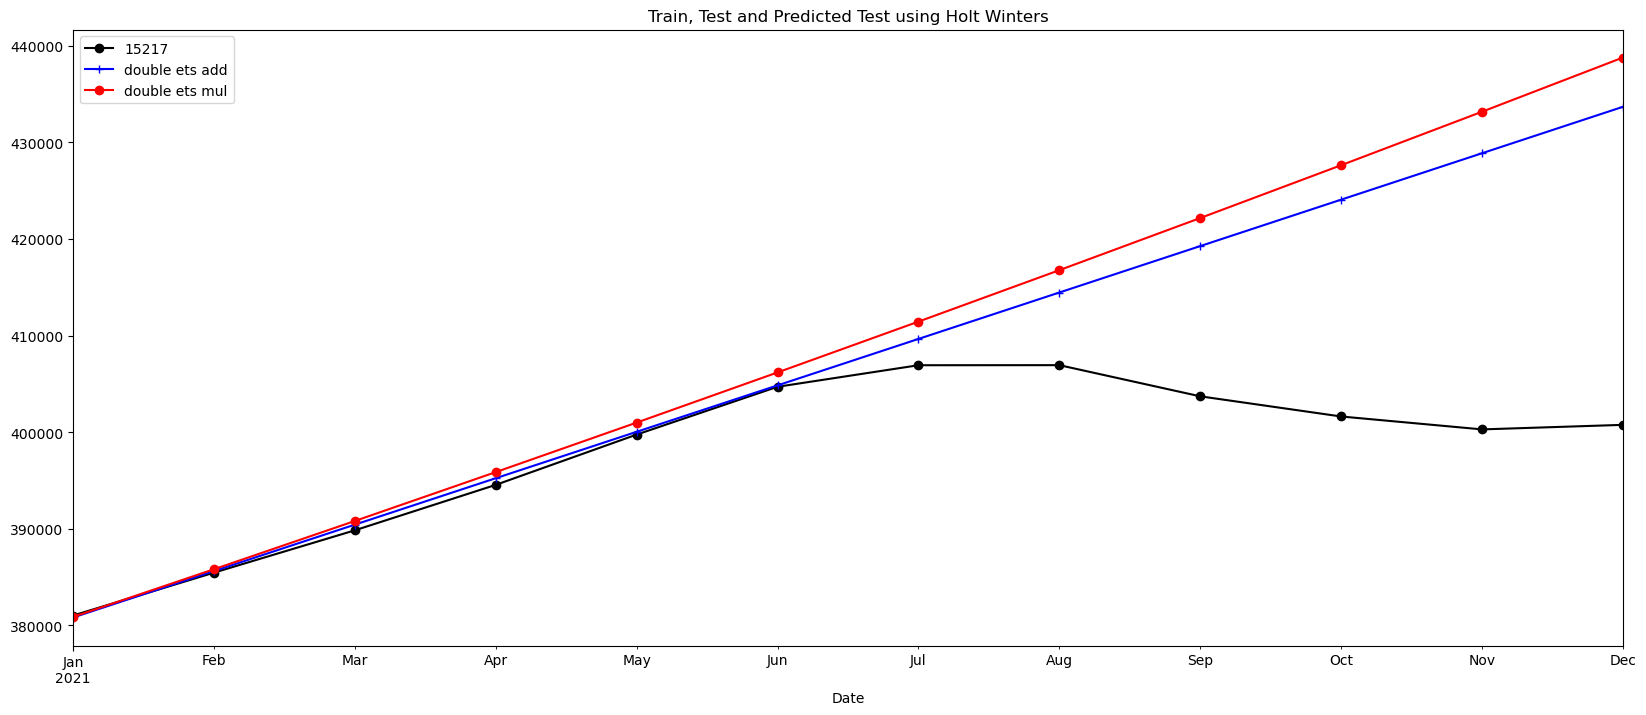

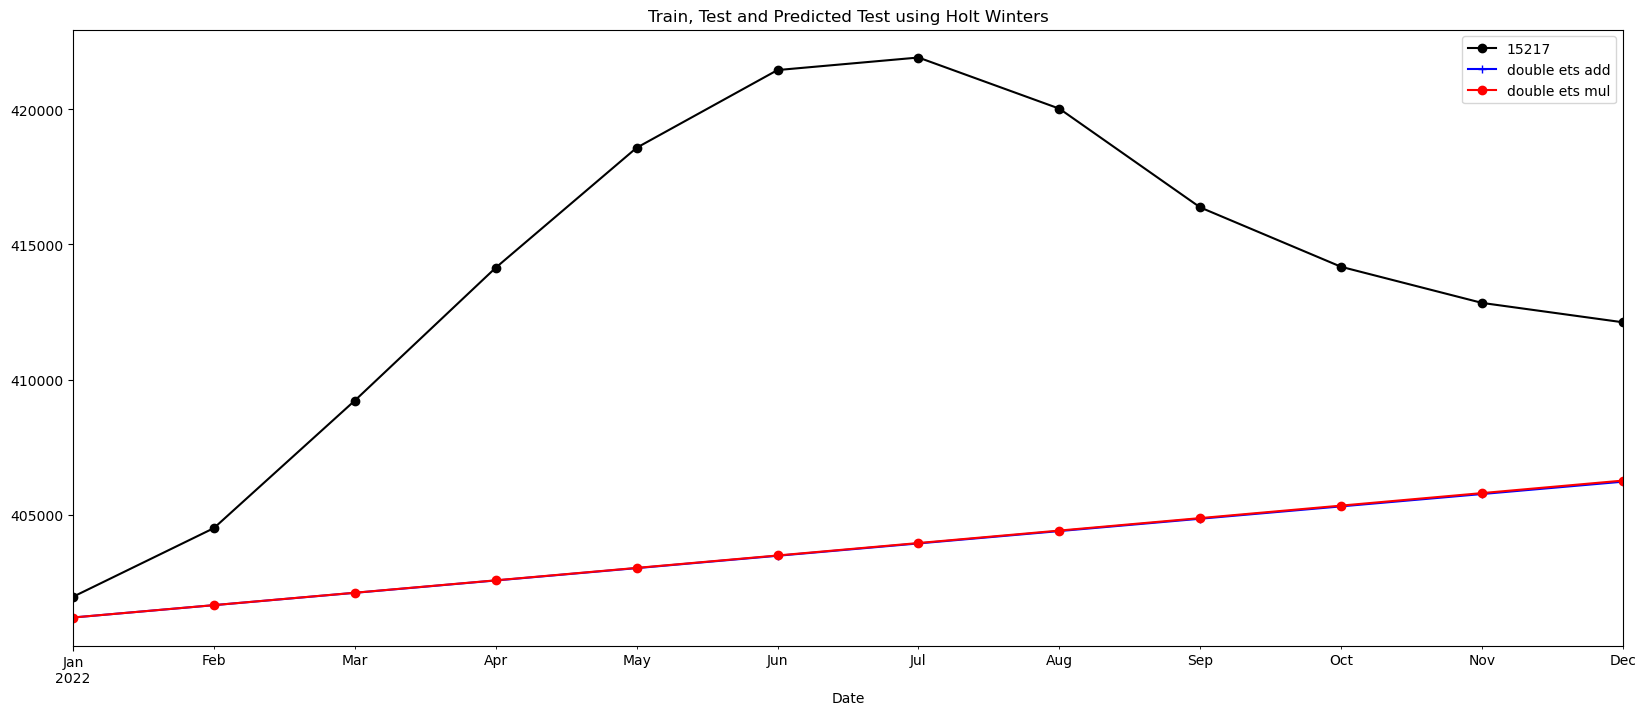

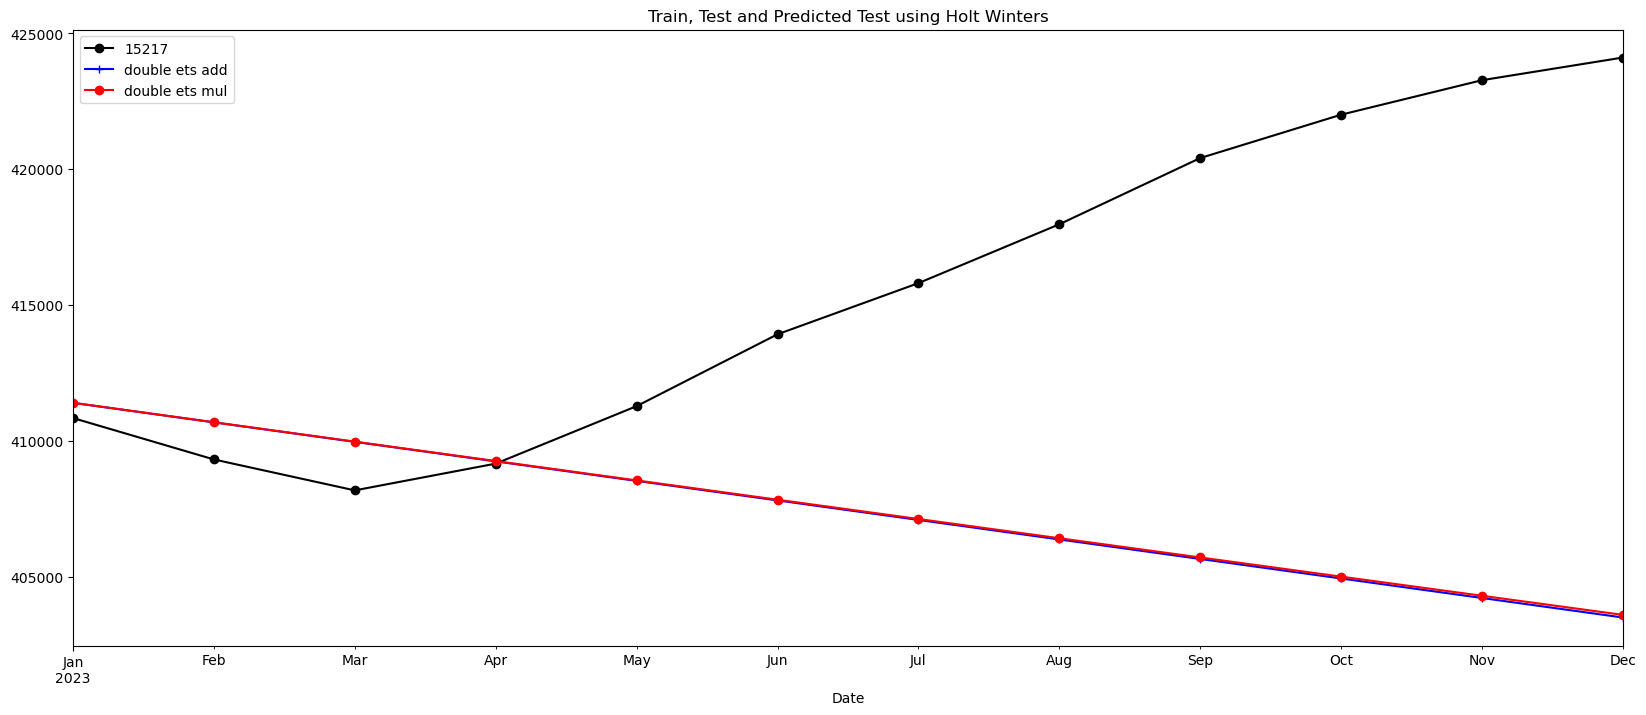

In [64]:
doubleADD, doubleMul=forecastDoubleETS()

In [147]:
df_var=pd.DataFrame(house_df[['15218', '15213', '15217']])
df_var

,15218,15213,15217
Date,,,
2000-01-31,66579.81966,70426.27384,131509.7320
2000-02-29,66485.36342,69924.98175,131542.6826
2000-03-31,66487.65160,69916.60187,131758.5483
2000-04-30,66621.59987,69802.21239,132212.5761
2000-05-31,66900.56593,70537.40009,133109.8232
...,...,...,...
2023-11-30,202354.65330,282149.60410,423272.6920
2023-12-31,202974.54460,281536.64560,424106.3329
2024-01-31,203731.92370,280785.04990,425256.6425


In [154]:
first_diff_var=df_var.diff().dropna()

from statsmodels.tsa.stattools import adfuller

# Assuming 'first_diff_df' is your differenced DataFrame
for column in first_diff_var.columns:
    result = adfuller(first_diff_var[column])
    print(f'Results for column: {column}')
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    print('\n')  # Just to add a new line for better readability between columns

Results for column: 15218
ADF Statistic: -3.031588
p-value: 0.032048
Critical Values:
	1%: -3.455
	5%: -2.872
	10%: -2.572


Results for column: 15213
ADF Statistic: -3.541826
p-value: 0.006976
Critical Values:
	1%: -3.455
	5%: -2.872
	10%: -2.572


Results for column: 15217
ADF Statistic: -3.505965
p-value: 0.007835
Critical Values:
	1%: -3.455
	5%: -2.872
	10%: -2.572




### Take the first diff of df_var, check its ADF stats, so that it is stationary before applying VAR. 

In [155]:
 # return forecasts with VAR model for one period
def var(train_data, test_data):
    first_diff_var=train_data.diff().dropna()
    var = VAR(first_diff_var)
    x= var.select_order()
    x.summary()
    
    var_results = var.fit(6)
    #We can check the summary of the model by.
    var_results.summary()
    
    fig = var_results.plot_forecast(12);
    fig.set_size_inches(20, 10, forward=True)
    
    #predictions
    var_pred = var_results.forecast(var_results.endog, steps=12)
    #var_pred
    
    
    # Assuming you have a DataFrame named 'train_data' which contains the original data
    # and 'var_pred' is your differenced forecasted values as a numpy array

    # Get the last actual observed value for each column
    last_observed_values = train_data.iloc[-1]

    # Initialize an empty DataFrame with the same indices and columns as 'var_pred'
    undiff_var_pred = pd.DataFrame(index=test_data.index, columns=test_data.columns)

    # Perform the cumulative sum to undifference the data
    # Start by adding the last observed value to the first differenced forecast
    undiff_var_pred.iloc[0] = last_observed_values + var_pred[0]

    # Now add the differenced forecasts to each subsequent forecast
    for i in range(1, len(var_pred)):
        undiff_var_pred.iloc[i] = undiff_var_pred.iloc[i-1] + var_pred[i]

    # Round the values to 2 decimal places if necessary
    undiff_var_pred = undiff_var_pred.round(2)

    # Show the undifferenced forecast DataFrame
    # print(undiff_var_pred)
    
#     ax = test_data['15217'].plot(marker='o', color='black', figsize=(20,8), legend=True)

#     undiff_var_pred['15217'].plot(marker='o', ax=ax, color='green', legend=True, label = 'new var')

#     plt.title('Train, Test and Predicted Based on Stationary Train Data')
#     plt.show()
    
    return  undiff_var_pred['15217']
    

In [156]:
# return VAR forecasts as dictionary for each test period
def forecastVar(): 
    
    forecast_results = {}

    # Loop through each test period, split the data, run ARIMA, and store the forecast
    for i, period in enumerate(test_periods):
        train_data, test_data = split_data(df_var, *period)
        forecast = var(train_data, test_data)
        forecast_results[f'period_{i}'] = forecast

    # To display the forecast results for each period
    for period, forecast in forecast_results.items():
        print(f"Forecast for {period}: {forecast}")
        
    return forecast_results

/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/qt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


Forecast for period_0: Date
2020-01-31    356677.650872
2020-02-29    357490.847097
2020-03-31    358400.229421
2020-04-30    359519.780165
2020-05-31    360466.447741
2020-06-30    361212.053034
2020-07-31    361755.679387
2020-08-31    362339.593385
2020-09-30    363020.841138
2020-10-31    363828.073943
2020-11-30    364653.833536
2020-12-31    365472.533632
Name: 15217, dtype: object
Forecast for period_1: Date
2021-01-31    380818.011507
2021-02-28    384481.582093
2021-03-31    387265.294848
2021-04-30    389123.095757
2021-05-31    390483.589552
2021-06-30    391246.462048
2021-07-31    391788.252775
2021-08-31    392257.788161
2021-09-30    392937.393658
2021-10-31    393748.571257
2021-11-30    394692.676254
2021-12-31     395681.98244
Name: 15217, dtype: object
Forecast for period_2: Date
2022-01-31    400688.651815
2022-02-28    401068.605284
2022-03-31    401335.556884
2022-04-30    402804.795829
2022-05-31    404447.299907
2022-06-30    406411.971102
2022-07-31    407779.3

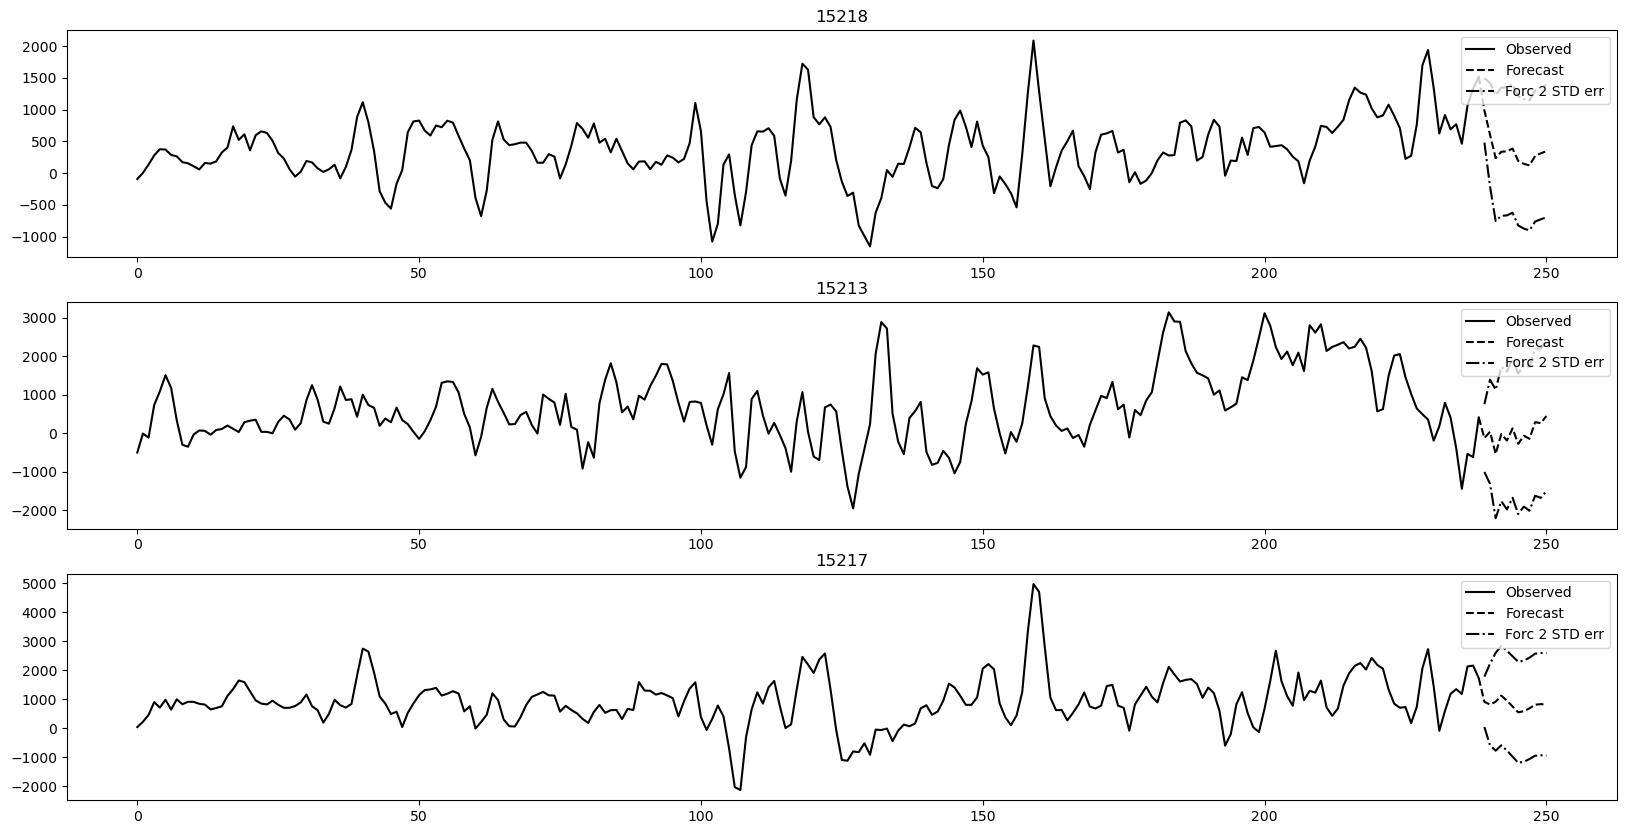

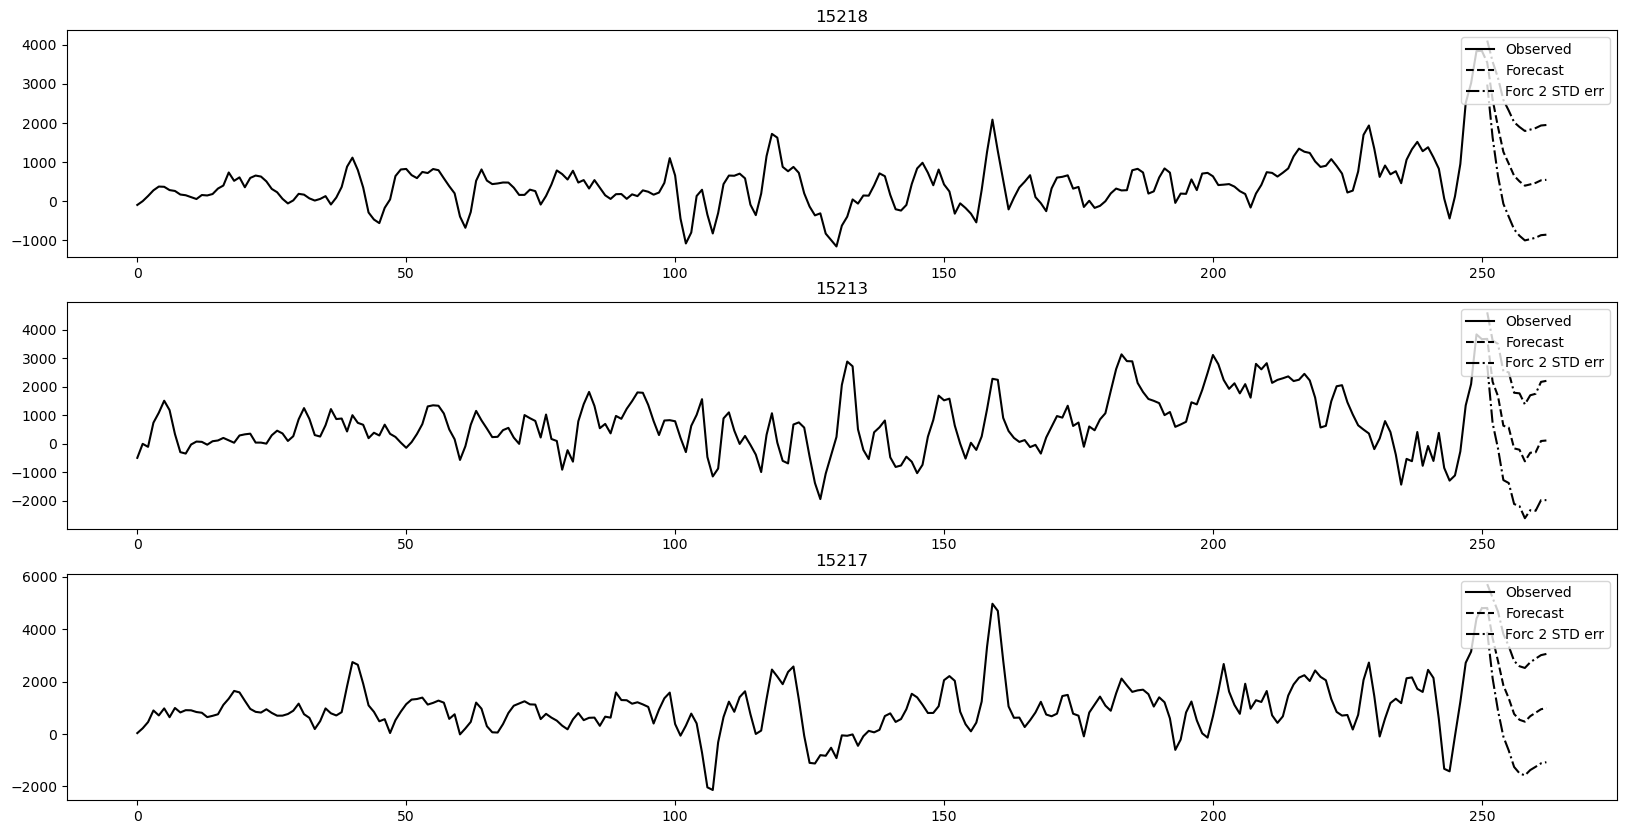

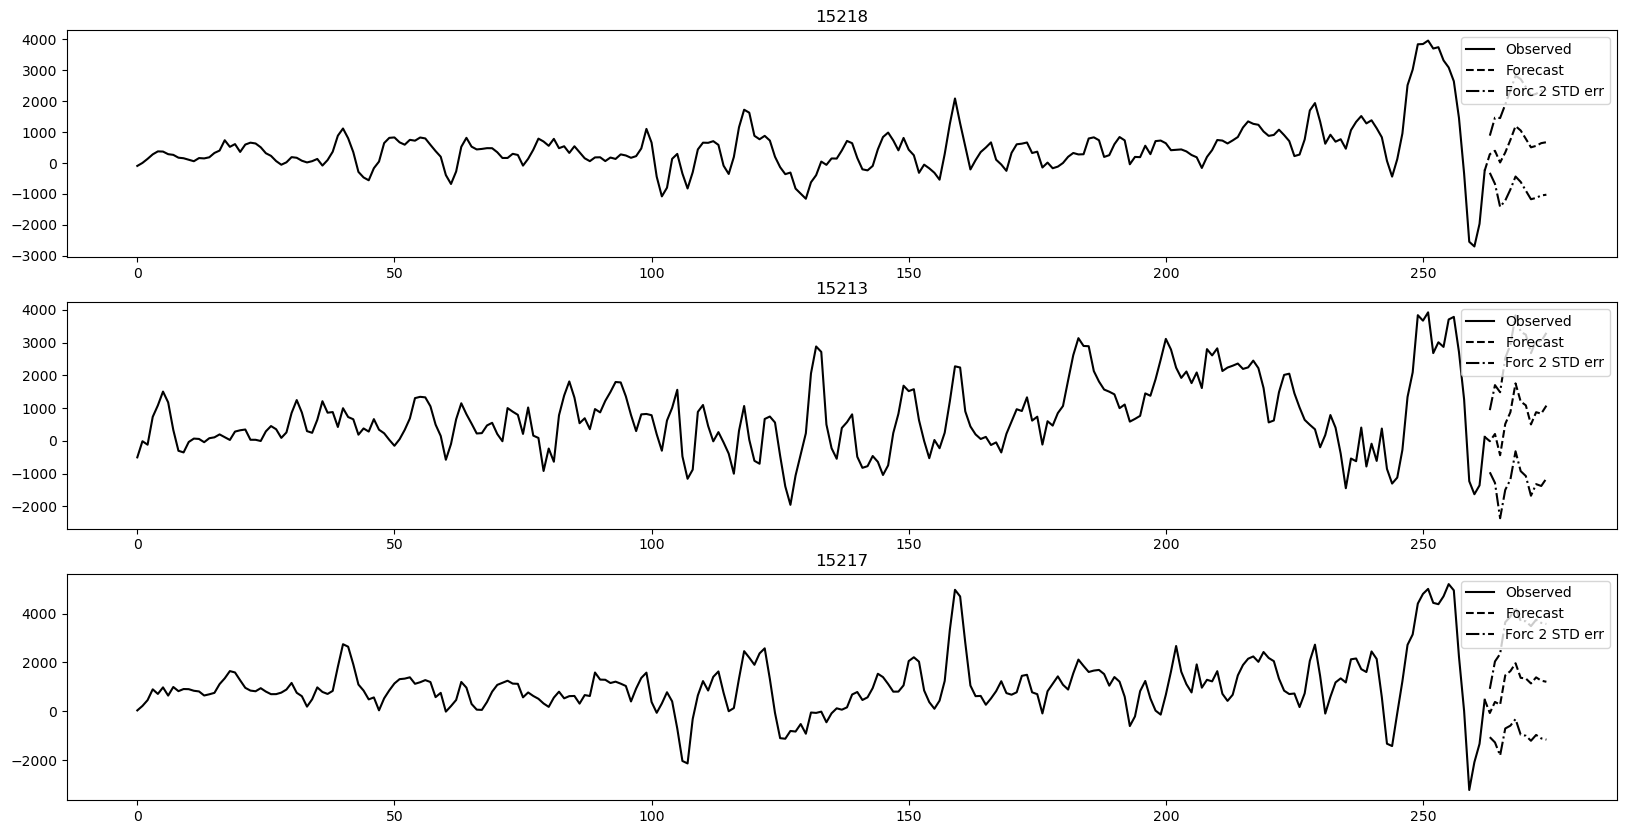

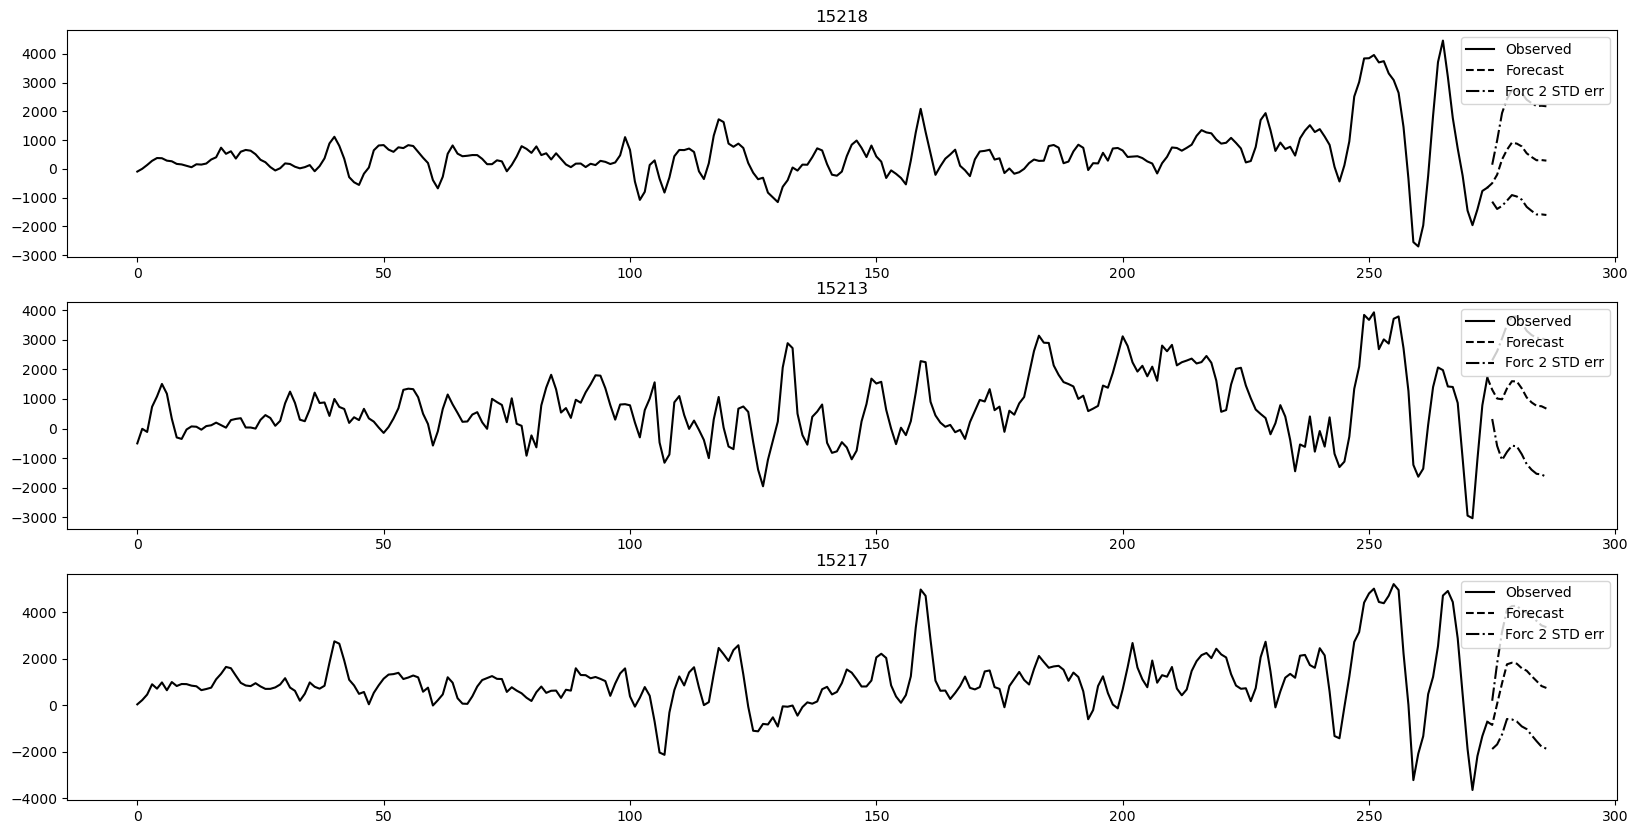

In [157]:
var_forecasts=forecastVar()

## Auto Arima Seasonal

In [69]:
# Auto ARIMA Seasonal function to get Auto ARIMA Seasonal model, forecasted series, and plot the graph
def auto_Arima_seasonal(train_data, test_data): 
    smodel = pm.auto_arima(train_data, start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=None, D=1, trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

    smodel.summary()
    # Forecast
    n_periods = 12
    fc_auto_seasonal, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
    print("\nfc_auto_seasonal:")
    print(fc_auto_seasonal)
    
    # make series for plotting purpose
    fc_series_auto_seasonal = pd.Series(fc_auto_seasonal, index=test_data.index)
    lower_series = pd.Series(confint[:, 0], index=test_data.index)
    upper_series = pd.Series(confint[:, 1], index=test_data.index)

    # Plot
    plt.figure(figsize=(12,5), dpi=100)
    plt.plot(train_data, label='training')
    plt.plot(test_data, label='test')
    plt.plot(fc_series_auto_seasonal, label='forecast')
    plt.fill_between(lower_series.index, lower_series, upper_series,
                     color='k', alpha=.15)
    plt.title('Forecast vs Actuals')
    plt.legend(loc='upper left', fontsize=8)
    plt.show()
    
    return fc_series_auto_seasonal 

In [70]:
# return Sarima forecasts as dictionary for each test period
def forecastSarima(): 
    
    forecast_results = {}

    # Loop through each test period, split the data, run ARIMA, and store the forecast
    for i, period in enumerate(test_periods):
        train_data, test_data = split_data(df_var['15217'], *period) # only 1 variable needed
        forecast = auto_Arima_seasonal(train_data, test_data)
        forecast_results[f'period_{i}'] = forecast

    # To display the forecast results for each period
    for period, forecast in forecast_results.items():
        print(f"Forecast for {period}: {forecast}")
        
    return forecast_results

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=1.03 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=4584.222, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=4527.982, Time=0.15 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=4951.430, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=4518.371, Time=0.14 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=4528.431, Time=0.21 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=4529.973, Time=0.29 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=4691.000, Time=0.40 sec
 ARIMA(0,0,2)(0,1,0)[12] intercept   : AIC=4525.607, Time=0.07 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=4514.485, Time=0.24 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=4652.840, Time=0.95 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.52 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=4653.592, Time=0.36 sec
 ARIMA(2,0,1)(0,1,0)[12] intercept 

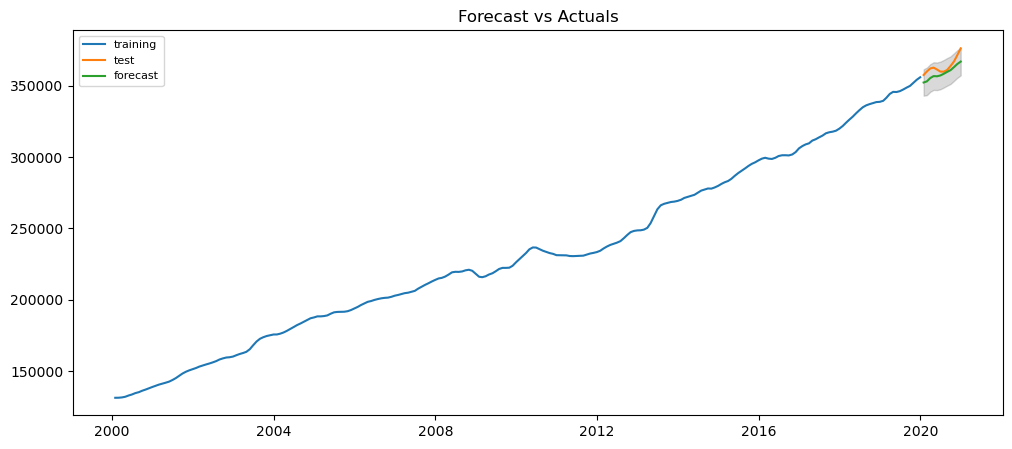

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=1.18 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=4823.922, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=4763.085, Time=0.16 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=5219.781, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=4764.429, Time=0.05 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=4765.077, Time=0.56 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=4764.856, Time=0.40 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=4763.591, Time=0.23 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=4766.855, Time=0.79 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=4825.796, Time=0.07 sec
 ARIMA(0,0,2)(0,1,1)[12] intercept   : AIC=4756.518, Time=0.24 sec
 ARIMA(0,0,2)(0,1,0)[12] intercept   : AIC=4760.368, Time=0.07 sec
 ARIMA(0,0,2)(1,1,1)[12] intercept   : AIC=4758.458, Time=0.42 sec
 ARIMA(0,0,2)(0,1,2)[12] inter

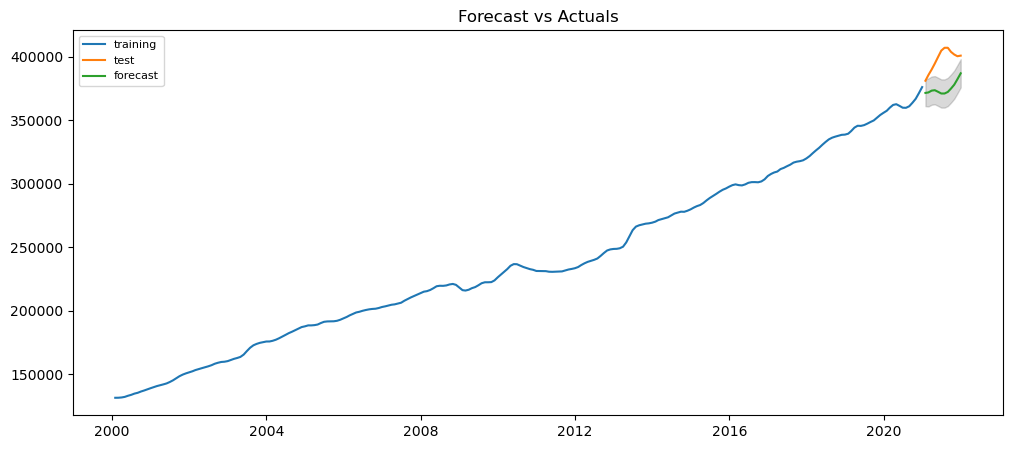

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.89 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=5218.967, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=5128.572, Time=0.19 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=5551.362, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=5129.742, Time=0.07 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=5130.571, Time=0.42 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=5130.524, Time=0.32 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=5129.090, Time=0.27 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=5132.524, Time=1.21 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=5220.771, Time=0.08 sec
 ARIMA(0,0,2)(0,1,1)[12] intercept   : AIC=5109.781, Time=0.24 sec
 ARIMA(0,0,2)(0,1,0)[12] intercept   : AIC=5114.029, Time=0.08 sec
 ARIMA(0,0,2)(1,1,1)[12] intercept   : AIC=5111.701, Time=0.50 sec
 ARIMA(0,0,2)(0,1,2)[12] inter

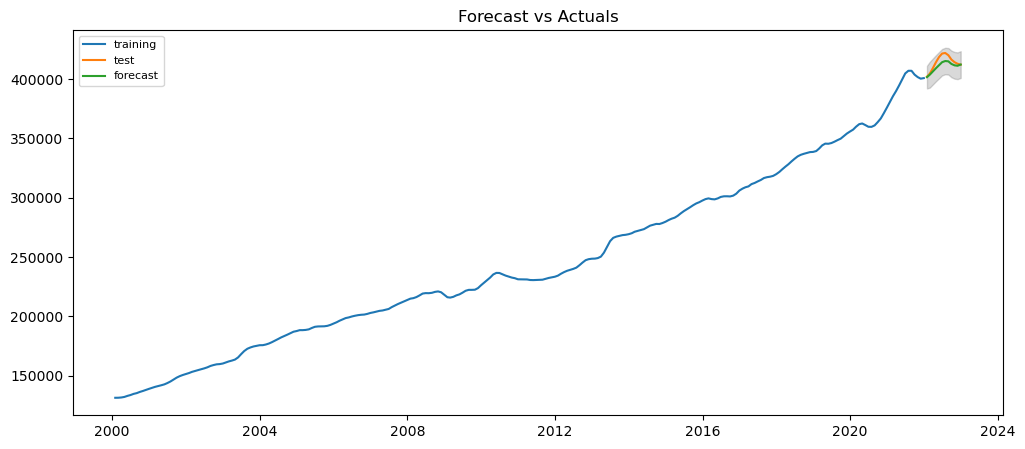

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=1.82 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=5459.912, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=5393.233, Time=1.01 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=5364.377, Time=0.14 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=5818.500, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=5365.157, Time=0.05 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=5366.373, Time=0.32 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=5366.332, Time=0.39 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=5336.107, Time=0.39 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=5366.684, Time=0.83 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=5368.338, Time=1.63 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=5461.864, Time=0.29 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=5405.173, Time=1.01 sec
 ARIMA(0,0,2)(1,1,0)[12] intercept   : AIC=5346.595, Time=0.28 sec
 ARIMA(1,0,2)(1,1,0)[12]

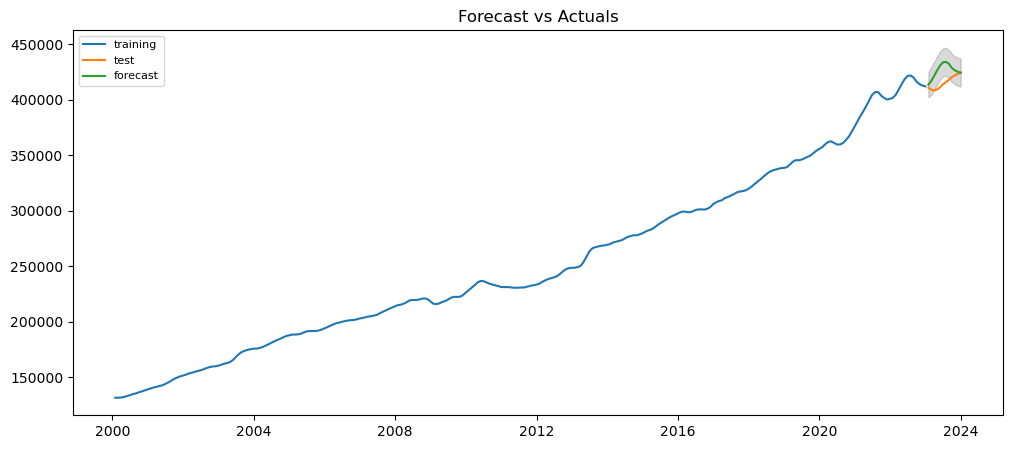

Forecast for period_0: Date
2020-01-31    352121.629182
2020-02-29    352907.500577
2020-03-31    355263.166628
2020-04-30    356601.002197
2020-05-31    356472.572240
2020-06-30    357052.734182
2020-07-31    358230.341472
2020-08-31    359574.193852
2020-09-30    360751.013252
2020-10-31    362877.364057
2020-11-30    365036.920067
2020-12-31    366760.248312
dtype: float64
Forecast for period_1: Date
2021-01-31    371419.697287
2021-02-28    371786.339460
2021-03-31    373221.354665
2021-04-30    373546.713232
2021-05-31    372285.453790
2021-06-30    370965.066320
2021-07-31    370952.601642
2021-08-31    372186.341222
2021-09-30    374825.010633
2021-10-31    377913.654062
2021-11-30    382203.923991
2021-12-31    386847.618992
dtype: float64
Forecast for period_2: Date
2022-01-31    401582.785891
2022-02-28    403634.966897
2022-03-31    406417.103323
2022-04-30    409088.102920
2022-05-31    411680.446333
2022-06-30    414176.424642
2022-07-31    415146.977283
2022-08-31    4148

In [71]:
sarima_forecasts=forecastSarima()

## Sarimax model

In [151]:
# return Sarimax forecast for one period as dataframe
def sarimax(train_data, test_data):
    sxmodel = pm.auto_arima(train_data[['15217']], exogenous=train_data[['15213', '15218']],
                           start_p=0, start_q=0,
                           test='adf',
                           max_p=3, max_q=3, m=12,
                           start_P=0, seasonal=True,
                           d=1, D=1, trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
    sxmodel.summary()
    
    sarimax_pred = sxmodel.predict(n_periods=12, exogenous=test_data[['15213', '15218']])
    #converting predictions to dataframe
    sarimax_pred = pd.DataFrame(index=test_data.index,columns=['15217'], data = sarimax_pred.round(2))
    return sarimax_pred

# return Sarimax forecasts for all test periods as a dictionary
def forecastSarimax(): 
    forecast_results = {}

    # Loop through each test period, split the data, run ARIMA, and store the forecast
    for i, period in enumerate(test_periods):
        train_data, test_data = split_data(df_var, *period) # only 1 variable needed
        forecast = sarimax(train_data, test_data)
        forecast_results[f'period_{i}'] = forecast

    # To display the forecast results for each period
    for period, forecast in forecast_results.items():
        print(f"Forecast for {period}: {forecast}")
        
    return forecast_results
    

In [77]:
sarimax_forecasts=forecastSarimax()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=3886.603, Time=0.14 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3889.968, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=3881.161, Time=0.38 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=3881.334, Time=0.50 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=3884.258, Time=0.10 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=3881.897, Time=0.63 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=3881.515, Time=0.58 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=3880.947, Time=0.33 sec
 ARIMA(1,1,0)(0,1,2)[12]             : AIC=3881.817, Time=1.11 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=inf, Time=1.71 sec
 ARIMA(2,1,0)(0,1,1)[12]             : AIC=3881.161, Time=0.44 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=0.79 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=3884.340, Time=0.69 sec
 ARIMA(1,1,0)(0,1,1)[12] intercept   : AIC=3882.692, Time=0.46 sec

Best model:  ARIMA(1,1,0)(0,

## Model evaluation

In [152]:
def calculate_metrics(actuals, predictions, model_name):
    # Calculate metrics
    r2 = metrics.r2_score(actuals, predictions)
    mse = metrics.mean_squared_error(actuals, predictions)
    rmse = sqrt(mse)
    mae = metrics.mean_absolute_error(actuals, predictions)
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

    # Create and return a DataFrame with the metrics
    return pd.DataFrame({
        'Model': [model_name],
#         'R2': [r2],
        'RMSE': [rmse],
        'MAE': [mae],
        'MAPE': [mape]
    })

# return models metrics sorted by MAE for one period
def modelEvaluation(i):
    #define metrics dataframe which will be used below for
    metrics_dataframe = pd.DataFrame(columns=['Model', 'R2', 'RMSE', 'MAE', 'MAPE'])
    # Initialize a list to hold the DataFrame for each set of metrics
    metrics_list = []
    # get average of top 3 models
    avg_pred = (arima_nonseasonal_forecasts[f'period_{i}'].values.flatten()+
           tripleMul_forecasts[f'period_{i}'].values.flatten()+
            var_forecasts[f'period_{i}'].values.flatten()                                                                                                 
          )/3
    # add index for avg_pred
    avg_df=pd.DataFrame(avg_pred, index=tripleMul_forecasts[f'period_{i}'].index, columns=['Average'])

    # Generate metrics for each model and add the resulting DataFrame to the list
    metrics_list.append(calculate_metrics(test_data['15217'].values.flatten(),
                                          tripleAdd_forecasts[f'period_{i}'].values.flatten(),
                                          'Triple Add'))

    metrics_list.append(calculate_metrics(test_data['15217'].values.flatten(),
                                          tripleMul_forecasts[f'period_{i}'].values.flatten(),
                                          'Triple Mul'))

    metrics_list.append(calculate_metrics(test_data['15217'].values.flatten(),
                                          sarima_forecasts[f'period_{i}'].values.flatten(),
                                          'SARIMA'))

    metrics_list.append(calculate_metrics(test_data['15217'].values.flatten(),
                                      var_forecasts[f'period_{i}'].values.flatten(),
                                          'VAR'))

    metrics_list.append(calculate_metrics(test_data['15217'].values.flatten(),
                                          sarimax_forecasts[f'period_{i}'].values.flatten(),
                                          'SARIMAX'))
    metrics_list.append(calculate_metrics(test_data['15217'].values.flatten(),
                                          arima_nonseasonal_forecasts[f'period_{i}'].values.flatten(),
                                          'arima_nonseasonal'))
      # take averge of top 3 models as 'Average'
    avg_pred = (arima_nonseasonal_forecasts[f'period_{i}'].values.flatten()+
                                                       tripleMul_forecasts[f'period_{i}'].values.flatten()+
                                                        var_forecasts[f'period_{i}'].values.flatten()                                                                                                 
                                                      )/3
    metrics_list.append(calculate_metrics(test_data['15217'].values.flatten(),
                                          avg_pred.flatten(),
                                          'Average'))


    # Concatenate all the DataFrames in the list into one DataFrame
    metrics_dataframe = pd.concat(metrics_list, ignore_index=True)
    #metrics_dataframe.sort_values(by="MAE", ascending=True)
    return metrics_dataframe


In [145]:
# def modelEvaluationAll(): 
#     forecast_results = {}

# Loop through each test period, split the data, run ARIMA, and store the forecast
for i, period in enumerate(test_periods):
    train_data, test_data = split_data(df_var, *period) # only 1 variable needed
    forecast=modelEvaluation(i)  

    forecast_results[f'period_{i}'] = forecast

# To display the forecast results for each period
for period, forecast in forecast_results.items():
#     
    forecast.sort_values(by="MAE", ascending=True, inplace=True)
    print(f"Model Evaluation for {period}: \n{forecast}")
        
#     return forecast_results

Model Evaluation for period_0: 
               Model         RMSE          MAE      MAPE
4            SARIMAX  2883.039887  2312.244075  0.637051
5  arima_nonseasonal  3561.812761  2742.044374  0.747432
6            Average  3522.233767  2943.309182  0.810576
3                VAR  4216.905763  3088.224484  0.839832
2             SARIMA  5296.778246  4776.513957  1.309830
0         Triple Add  6964.035926  5518.566242  1.516849
1         Triple Mul  9803.463239  7815.999883  2.143488
Model Evaluation for period_1: 
               Model          RMSE           MAE      MAPE
6            Average   6970.470782   6093.363464  1.522141
3                VAR   7710.149511   6155.799517  1.528993
0         Triple Add  17439.106948  11377.700261  2.831690
4            SARIMAX  16284.308928  14080.742450  3.505700
5  arima_nonseasonal  16689.433588  15557.011856  3.881514
1         Triple Mul  23070.614769  15746.794649  3.917177
2             SARIMA  24680.485346  23119.808675  5.774415
Model Ev

### Based on the model evaluation over 4 test periods, we choose 'Average' because it ranks among the top 3. 

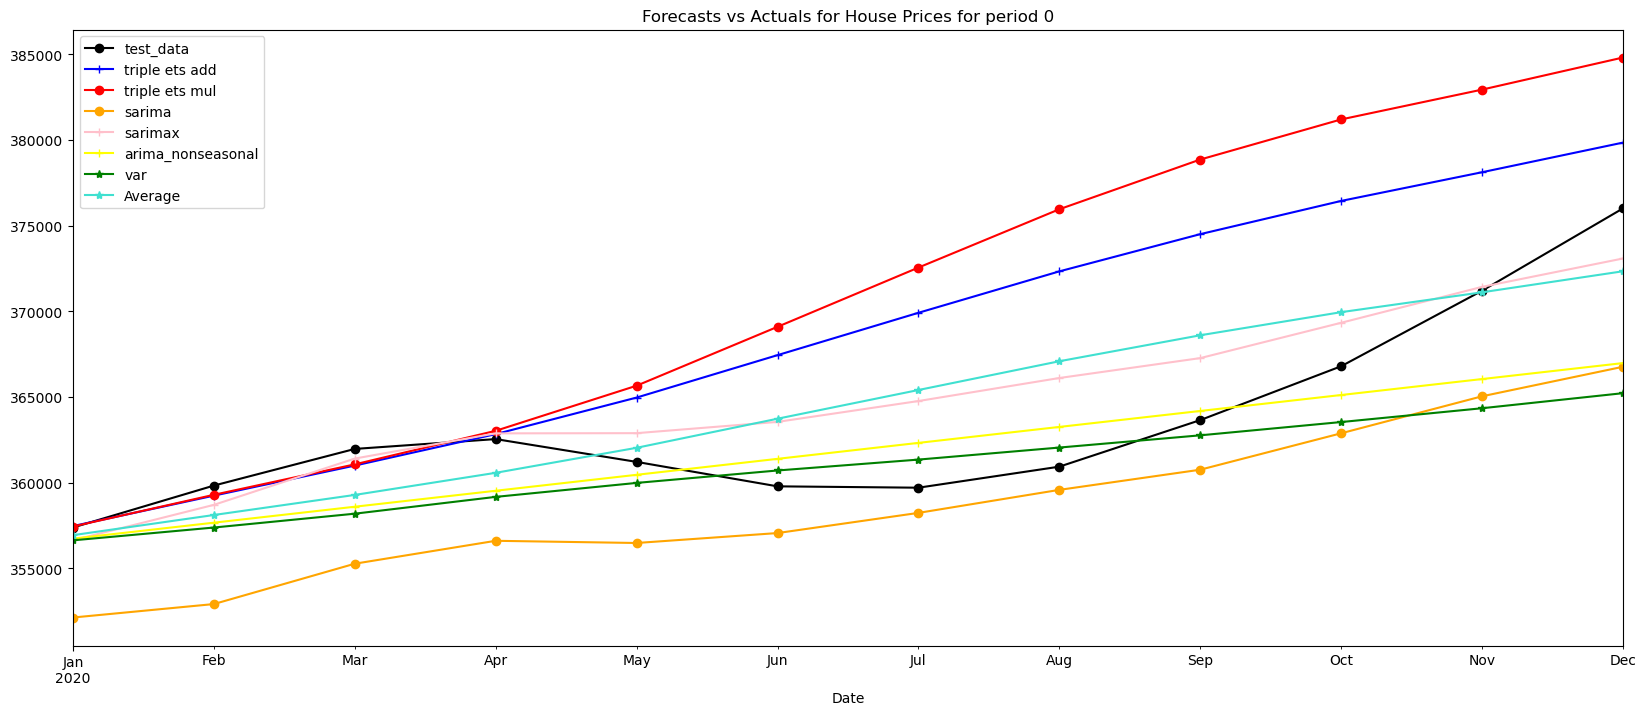

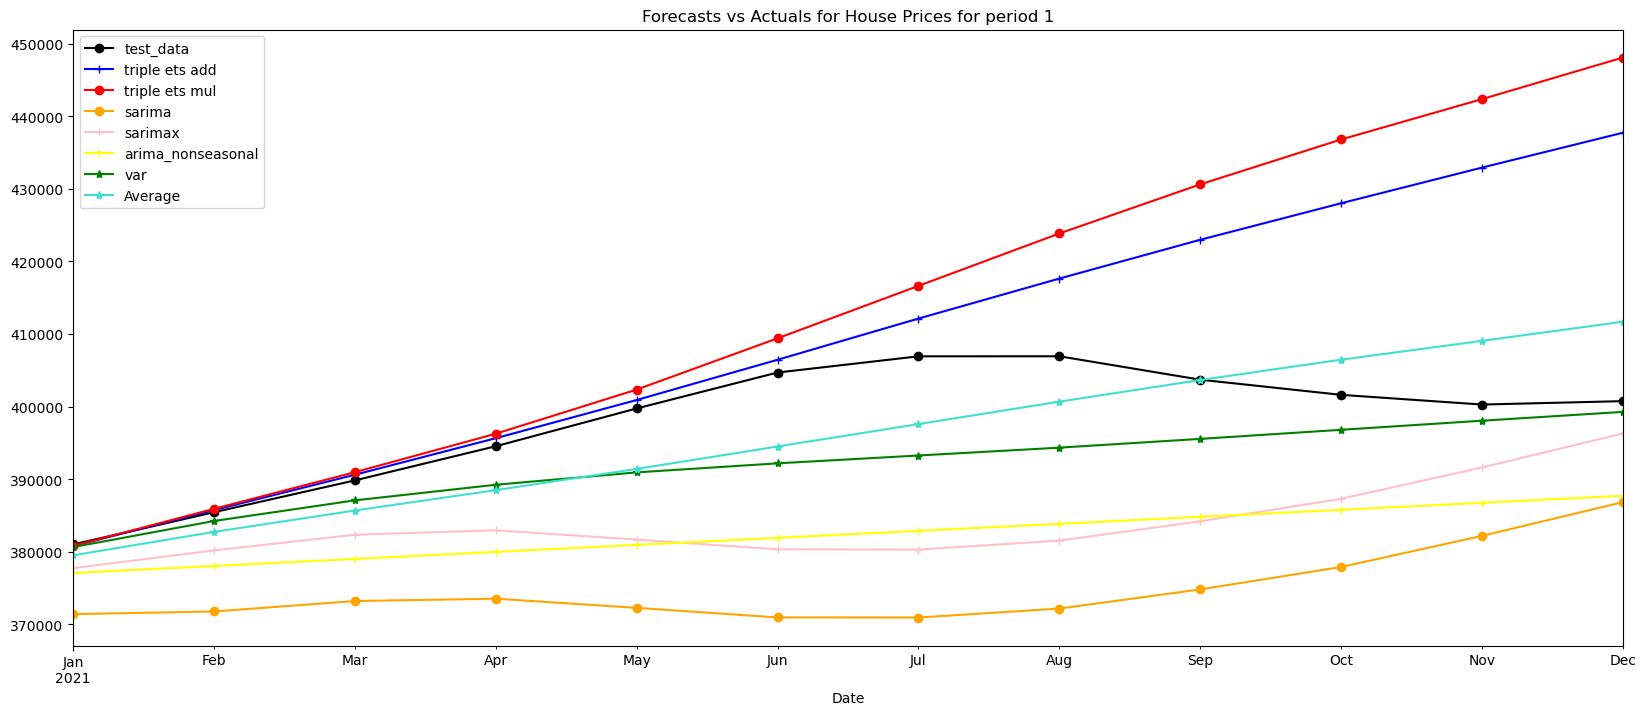

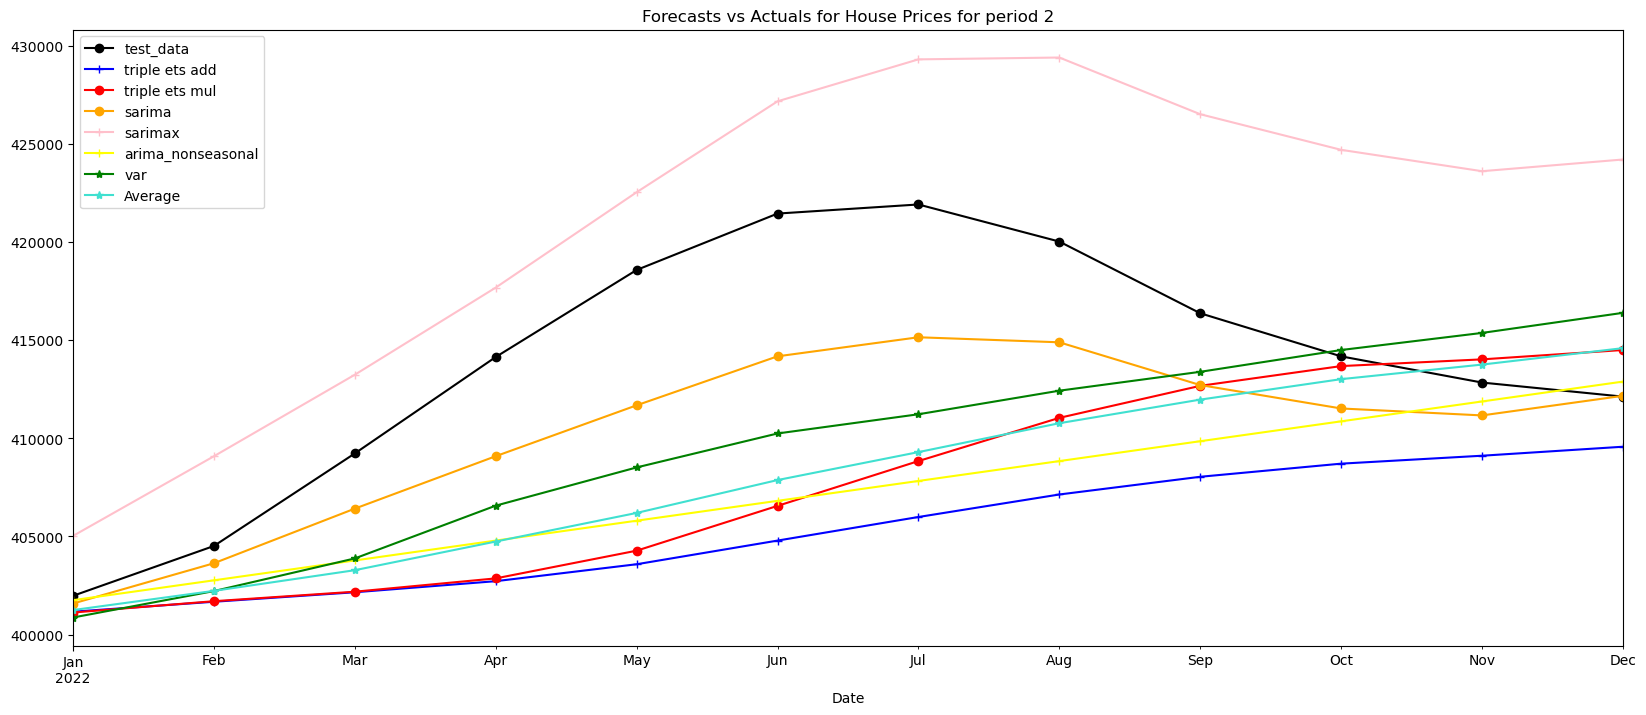

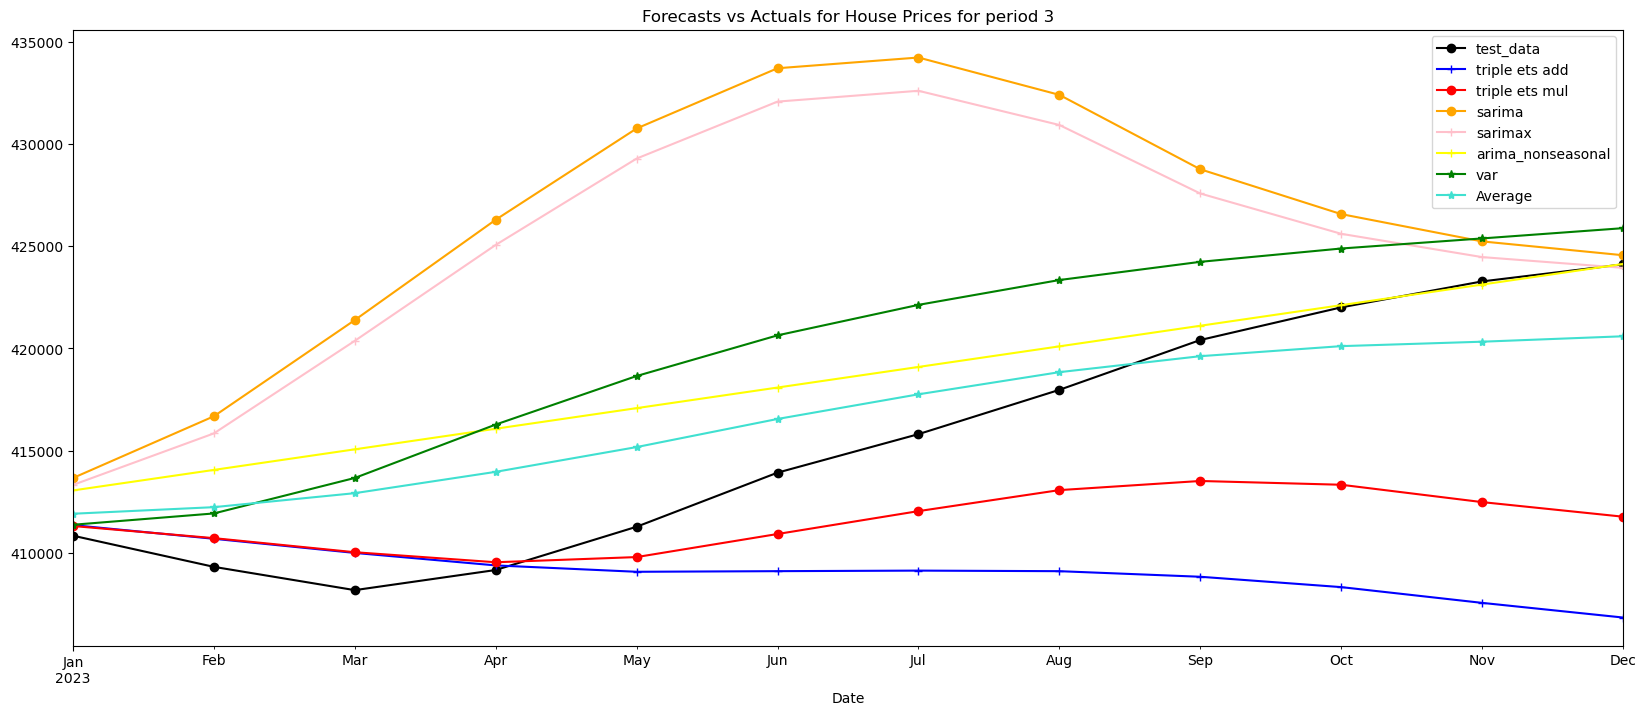

In [153]:
# plot actuals vs forecasts for all periods

for i, period in enumerate(test_periods):
    train_data, test_data = split_data(house_price, *period)
    avg_pred = (arima_nonseasonal_forecasts[f'period_{i}'].values.flatten() +
                tripleMul_forecasts[f'period_{i}'].values.flatten() +
                var_forecasts[f'period_{i}'].values.flatten()) / 3
    avg_df = pd.DataFrame(avg_pred, index=tripleMul_forecasts[f'period_{i}'].index, columns=['Average'])
    #  rename column names
    sarimax_forecasts[f'period_{i}'] = sarimax_forecasts[f'period_{i}'].rename(columns={'15217': 'sarimax'})
    test_data=test_data.rename(columns={'15217':'test_data'})
    

    ax = test_data.plot(marker='o', color='black', figsize=(20,8), legend=True)
    
    tripleAdd_forecasts[f'period_{i}'].plot(marker='+', ax=ax, color='blue', legend=True, label = 'triple ets add')

    tripleMul_forecasts[f'period_{i}'].plot(marker='o', ax=ax, color='red', legend=True, label = 'triple ets mul')

    sarima_forecasts[f'period_{i}'].plot(marker='o', ax=ax, color='orange', legend=True, label = 'sarima')
    sarimax_forecasts[f'period_{i}'].plot(marker='+', ax=ax, color='pink', legend=True, label = 'sarimax')
    arima_nonseasonal_forecasts[f'period_{i}'].plot(marker='+', ax=ax, color='yellow', legend=True, label = 'arima_nonseasonal')

    var_forecasts[f'period_{i}'].plot(marker='*', ax=ax, color='green', legend=True, label = 'var')

    avg_df.plot(marker='*', ax=ax, color='turquoise', legend=True)
    


    plt.title('Forecasts vs Actuals for House Prices for period {}'.format(i))

